# Paso 1: Recuperar y verificar los componentes del avance de proyecto.

## Tabla de trazabilidad — Avance de Proyecto

| Elemento | Archivo o ubicación | Versión | Estado | Acción requerida |
|---|---|---|---|---|
| Dataset | Se carga vía `kagglehub` (`blastchar/telco-customer-churn`), no hay CSV local en el repo | Consultado 25–31 ago 2026 | Disponible (requiere `kagglehub` y conexión) | Documentar que requiere autenticación/conexión a Kaggle |
| Pipeline | `Avance_Proyecto/Avance_Proyecto.ipynb` (Paso 13) | ColumnTransformer con imputación (constante 0 en numéricas), StandardScaler, OneHotEncoder, OrdinalEncoder | Corre limpio | Ninguna |
| Baseline | `Avance_Proyecto/Avance_Proyecto.ipynb` (Paso 14) | DummyClassifier (most_frequent) — Acc 0.7346, Recall 0.0000 | Completo | Ninguna |
| Modelo preliminar | `Avance_Proyecto/Avance_Proyecto.ipynb` (Pasos 15–19) | Regresión Logística (max_iter=1000, solver='lbfgs') — Acc 0.8055, F1 0.6040, ROC-AUC 0.8421 | Seleccionado y justificado | Ninguna |
| Métricas | `Avance_Proyecto/Avance_Proyecto.ipynb` (Paso 16) | Accuracy, Precision, Recall, F1, ROC-AUC para ambos modelos | Completo | Ninguna |
| Informe del avance de proyecto | `Avance_Proyecto/Avance_Proyecto.ipynb` (87 celdas) | Ejecutado 31 ago 2026, Python 3.14.7 | Corre de inicio a fin sin errores | Ninguna |

In [1]:
# Versiones del entorno de ejecución final (fijadas en requirements.txt)
import platform
from importlib.metadata import version

print(f"Python: {platform.python_version()}")
for paquete in ['scikit-learn', 'pandas', 'numpy', 'scipy', 'shap', 'matplotlib', 'joblib', 'kagglehub']:
    print(f"{paquete}: {version(paquete)}")

Python: 3.11.11
scikit-learn: 1.9.1
pandas: 3.0.6
numpy: 1.26.4
scipy: 1.12.0
shap: 0.44.1
matplotlib: 3.11.2
joblib: 1.6.0
kagglehub: 1.0.2


# Paso 2: Documentar la evolución del proyecto.

| Elemento modificado | Situación en avance de proyecto | Cambio realizado | Justificación | Impacto esperado |
|---|---|---|---|---|
| Datos | Telco Customer Churn (Kaggle, 7043 registros, 21 variables), cargado en tiempo de ejecución vía `kagglehub`. TotalCharges tenía tipo incorrecto (str) con 11 valores nulos ocultos, corregido a float64. Sin duplicados. Variable objetivo `Churn` con 26.5% de abandono (clase desbalanceada). | Sin cambios en el dataset base. Se repitió la revisión de calidad (nulos, duplicados, tipos, categorías, rangos, variables excluidas, balance de clases, fuga de información y correspondencia columnas-pipeline). | Verificar que los datos conservan las condiciones del avance antes de continuar, para que los resultados sean comparables. | Se confirma que los datos son consistentes: 11 nulos en `TotalCharges` (clientes con tenure 0, imputados con 0 dentro del pipeline), 0 duplicados, sin valores fuera de rango y balance 73.46% / 26.54%. |
| Preprocesamiento | ColumnTransformer con: imputación con constante 0 en numéricas, StandardScaler en tenure/MonthlyCharges/TotalCharges, OneHotEncoder en categóricas nominales, OrdinalEncoder en Contract. Partición 70/15/15 (train/val/test) estratificada, semilla 42. | `SeniorCitizen` y `PaperlessBilling` no estaban asignadas a ningún grupo del ColumnTransformer y pasaban por `remainder='passthrough'`. Se agregaron a `cols_bin` (imputación + OrdinalEncoder). El pipeline final incorpora además las variables nuevas `Total_Servicios` y `Cliente_Nuevo` como primer paso del pipeline. Se eliminó la partición 70/15/15: se usa una sola partición 80/20 estratificada (semilla 42) y la validación se hace con validación cruzada sobre el entrenamiento. | La revisión de correspondencia columnas-pipeline detectó variables sin transformación explícita. | Todas las variables pasan por imputación y codificación controlada, sin variables sin procesar. |
| Modelos | Baseline: DummyClassifier (most_frequent). Regresión Logística (max_iter=1000, solver='lbfgs') y Árbol de Decisión (max_depth=6, criterion='gini'). | Se reejecutaron los tres modelos del avance con el mismo preprocesador, semilla 42 y validación cruzada RepeatedStratifiedKFold 5x3. Se agregaron Random Forest (n_estimators=100, class_weight='balanced'), SVM (lineal, RBF estándar y RBF complejo, con class_weight='balanced') y MLPClassifier opcional (1 capa oculta de 100 neuronas, ReLU, early_stopping). Se optimizaron Random Forest y SVM RBF con GridSearchCV (mejores parámetros: Random Forest max_depth=6; SVM C=1, gamma=0.01). Se comparó el modelo completo (40 variables) con uno reducido (20 variables). Se registraron 6 experimentos (EXP-001 a EXP-006) en una bitácora y se seleccionaron como finalistas el Random Forest optimizado (Modelo A) y la Regresión Logística (Modelo B) con una matriz de criterios ponderados. | Comparar el modelo del avance contra alternativas más flexibles bajo el mismo protocolo, ajustar hiperparámetros de los candidatos más prometedores y elegir finalistas con criterios explícitos (Recall, Precision, F1, ROC-AUC, estabilidad, interpretabilidad y costo operativo) en lugar de una sola métrica. | Ningún modelo supera a la Regresión Logística en ROC-AUC de validación cruzada (0.8489, frente a 0.8475 del SVM lineal, 0.8473 del Random Forest optimizado, 0.8467 del SVM RBF optimizado y 0.8433 del MLP). La optimización mejoró mucho a Random Forest (0.8264 a 0.8473) y SVM RBF (0.8289 a 0.8467), pero solo los igualó. La reducción de 40 a 20 variables casi no cambia el ROC-AUC (0.8489 frente a 0.8477) y no se adoptó. Al haber empate en desempeño, se mantiene la Regresión Logística como modelo final por ser más ligera e interpretable. |
| Métricas | Regresión Logística: Accuracy 0.8055, Precision 0.6572, Recall 0.5588, F1 0.6040, ROC-AUC 0.8421. Árbol de Decisión: Accuracy 0.7913, Precision 0.6342, Recall 0.5053, F1 0.5625, ROC-AUC 0.8345. Baseline: Accuracy 0.7346, Recall 0.0000. | Las métricas se reportan como media de validación cruzada 5x3. Regresión Logística: ROC-AUC 0.8489, Recall 0.5382, F1 0.5956, Precision 0.6687, Accuracy 0.8065. Árbol: 0.8217 / 0.5282 / 0.5692 / 0.6231 / 0.7889. Random Forest: 0.8264 / 0.6453 / 0.6072 / 0.5739 / 0.7787. SVM lineal: 0.8475 / 0.8201 / 0.6248 / 0.5049 / 0.7387. SVM RBF estándar: 0.8289 / 0.7739 / 0.6264 / 0.5267 / 0.7551. SVM RBF complejo: 0.7964 / 0.7202 / 0.5968 / 0.5102 / 0.7420. MLP: ROC-AUC 0.8433. Baseline: ROC-AUC 0.5000, Accuracy 0.7346. Con GridSearchCV: Random Forest ROC-AUC 0.8473 y SVM RBF ROC-AUC 0.8467. | La validación cruzada da una estimación más estable que una sola partición y permite comparar todos los modelos con las mismas métricas y su desviación estándar (0.011 a 0.015 en ROC-AUC). | Recall y Precision se mueven en sentido opuesto: los SVM y el Random Forest ganan Recall (0.65 a 0.82) a costa de Precision (0.50 a 0.57). Como las diferencias de ROC-AUC entre los mejores modelos son pequeñas, no se interpretan como mejora real respecto al avance, que se midió con otra partición. |
| Umbral | Umbral estándar de 0.50 evaluado junto con 0.30 y 0.70 sobre Regresión Logística. Con 0.50: Precision 0.6522, Recall 0.5893, F1 0.6191. Sin curva explícita, solo tabla comparativa. | Se evaluaron umbrales sobre las probabilidades OOF de entrenamiento del Modelo B (validación cruzada estratificada de 5 particiones) con curva Precision-Recall, Índice de Youden (0.246), F1 máximo (0.317) y restricción de Recall ≥ 0.70 (0.365). Se construyó una tabla con 7 umbrales (0.25 a 0.70) y se seleccionó **0.32** (F1 máximo OOF, redondeado) como umbral operativo. El conjunto de prueba solo se usó para el reporte final. | En churn, un falso negativo (cliente perdido sin oportunidad de retención) suele costar más que un falso positivo (acción de retención innecesaria), por lo que se prioriza el Recall. | En prueba, con 0.32: Recall 0.7406 (vs 0.5321 con 0.50), Precision 0.5421, F1 0.6260; 97 falsos negativos (vs 175) a cambio de 234 falsos positivos (vs 101). Requiere validación organizacional de costos. |
| Interpretabilidad | Regresión Logística seleccionada como modelo preliminar por mejor ROC-AUC, mejor Recall, interpretabilidad de coeficientes y menor riesgo de sobreajuste frente al árbol. Sin ranking ni visualización de importancia. | Se calculó el ranking de variables por magnitud de coeficiente del Modelo B, con gráfica de las 15 variables más influyentes. Principales: `Contract` (-0.74), `Cliente_Nuevo` (+0.74), `InternetService_DSL` (-0.72), `tenure` (-0.66) y `InternetService_Fiber optic` (+0.63). Se comparó además la interpretabilidad de los modelos evaluados (coeficientes directos en la Regresión Logística, importancia global en Random Forest, MLP prácticamente no interpretable) y se evaluó un modelo reducido de 20 variables (ROC-AUC similar y mayor tiempo de cómputo), que no se adoptó. | Identificar qué factores impulsan la predicción de churn y validar que el modelo sea coherente con la lógica de negocio. | Se identifican como factores de riesgo los clientes nuevos, con internet de fibra óptica o sin contrato largo. Limitaciones: colinealidad (las categorías "No internet service" comparten coeficiente) y la influencia no implica causalidad. |

In [2]:
# --- Carga del dataset ---
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "blastchar/telco-customer-churn",
    file_path,
)

# --- Limpieza básica ---
# TotalCharges viene como texto: los valores vacíos quedan como nulos y se imputan dentro del pipeline (Paso 4)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# --- Separación de variables predictoras y objetivo ---
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'No': 0, 'Yes': 1})

# --- Partición train/test (80/20, estratificada). La validación se hace con validación cruzada sobre X_train ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

C:\Users\mmunozs\Downloads\ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Entrenamiento: (5634, 19), Prueba: (1409, 19)


In [3]:
# Pipeline del avance de proyecto (Paso 13), sin cambios. Se usa como referencia para la
# revisión de calidad del Paso 3; el pipeline final se define en el Paso 4.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# --- 1. Definición de columnas ---
cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges']
cols_bin = ['gender', 'Partner', 'Dependents', 'PhoneService']
cols_cat = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']
cols_ord = ['Contract']

# --- 2. Sub-pipelines por tipo de dato ---
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

pipe_bin = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

pipe_ord = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]))
])

# --- 3. Ensamblaje del ColumnTransformer ---
preprocesador = ColumnTransformer(
    transformers=[
        ('num', pipe_num, cols_num),
        ('bin', pipe_bin, cols_bin),
        ('cat', pipe_cat, cols_cat),
        ('ord', pipe_ord, cols_ord)
    ],
    remainder='passthrough'
)

# --- 4. Ajuste (Fit) SOLO en Train; Transformación en Train y Test ---
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep = preprocesador.transform(X_test)

print("Pipeline construido y aplicado exitosamente.")
print(f"Dimensiones originales de X_train: {X_train.shape}")
print(f"Dimensiones de X_train_prep (tras One-Hot Encoding): {X_train_prep.shape}")

Pipeline construido y aplicado exitosamente.
Dimensiones originales de X_train: (5634, 19)
Dimensiones de X_train_prep (tras One-Hot Encoding): (5634, 38)


# Paso 3: Revisar nuevamente la calidad de los datos.

In [4]:
# ============================================================
# Revisión de calidad de datos (Actividad "Revisar nuevamente
# la calidad de los datos") — verifica que el dataset conserve
# las condiciones definidas en el avance de proyecto.
# ============================================================

print("="*60)
print("1. VALORES FALTANTES")
print("="*60)
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("No hay valores nulos.")
else:
    print(f"TotalCharges nulos con tenure = 0: {(df['TotalCharges'].isna() & (df['tenure'] == 0)).sum()}")

print("\n" + "="*60)
print("2. DUPLICADOS")
print("="*60)
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"customerID duplicados: {df['customerID'].duplicated().sum()}")

print("\n" + "="*60)
print("3. TIPOS DE DATOS")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("4. CATEGORÍAS ÚNICAS POR VARIABLE CATEGÓRICA")
print("="*60)
cat_cols = df.select_dtypes(include=['object', 'str']).columns.drop('customerID')
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

print("\n" + "="*60)
print("5. VALORES FUERA DE RANGO (numéricas)")
print("="*60)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(df[num_cols].describe())
print(f"\ntenure negativo o >72 meses: {((df['tenure']<0)|(df['tenure']>72)).sum()}")
print(f"MonthlyCharges <= 0: {(df['MonthlyCharges']<=0).sum()}")

print("\n" + "="*60)
print("6. VARIABLES EXCLUIDAS DEL MODELADO")
print("="*60)
print("customerID: identificador único, sin valor predictivo -> excluida de X")
print(f"Columnas usadas en X: {list(X.columns)}")

print("\n" + "="*60)
print("7. BALANCE DE CLASES (variable objetivo)")
print("="*60)
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(4)*100)

print("\n" + "="*60)
print("8. POSIBLE FUGA DE INFORMACIÓN (fit solo en train)")
print("="*60)
print("Verificar: ¿el preprocesador se ajustó (fit) SOLO con X_train?")
print("-> Sí: fit_transform() se aplicó únicamente sobre X_train,")
print("   y transform() (sin fit) sobre X_test. Confirmar en la celda del pipeline.")

print("\n" + "="*60)
print("9. CORRESPONDENCIA ENTRE COLUMNAS Y PIPELINE")
print("="*60)
todas_cols_pipeline = set(cols_num + cols_bin + cols_cat + cols_ord)
todas_cols_X = set(X.columns)
faltantes_en_pipeline = todas_cols_X - todas_cols_pipeline
faltantes_en_X = todas_cols_pipeline - todas_cols_X
print(f"Columnas en X pero NO asignadas a ningún grupo del pipeline: {faltantes_en_pipeline}")
print(f"Columnas en el pipeline pero que NO existen en X: {faltantes_en_X}")
if not faltantes_en_pipeline and not faltantes_en_X:
    print("Correspondencia correcta: todas las columnas de X están cubiertas por el pipeline.")

1. VALORES FALTANTES
TotalCharges    11
dtype: int64
TotalCharges nulos con tenure = 0: 11

2. DUPLICADOS
Filas duplicadas: 0
customerID duplicados: 0

3. TIPOS DE DATOS
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

4. CATEGORÍAS ÚNICAS POR VARIABLE CATEGÓRICA
gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: st

In [5]:
# Corrección del hallazgo del punto 9: SeniorCitizen y PaperlessBilling se asignan a cols_bin
cols_bin = ['gender', 'Partner', 'Dependents', 'PhoneService', 'SeniorCitizen', 'PaperlessBilling']

Revision de la calidad de los datos:

Se verificaron los 9 puntos solicitados (valores faltantes, duplicados, tipos de datos, categorías, rango de valores, variables excluidas, balance de clases, fuga de información y correspondencia columnas-pipeline) sobre el dataset del avance de proyecto

Hallazgo y corrección: Las variables 'SeniorCitizen' y 'PaperlessBilling' no estan asignadas a ningún grupo del 'ColumnTransformer' y pasaban sin procesar vía 'remainder='passthrough'. Se corrigió agregándolas a 'cols_bin' para que reciban imputación y codificación explicita ('OrdinalEncoder')

Valores faltantes: `TotalCharges` tiene 11 nulos, todos de clientes con `tenure` = 0 (sin cargos acumulados). La revisión se ejecuta antes de imputar; los nulos se imputan con 0 dentro del pipeline (Paso 4).

Resto de puntos sin hallazgos. El dataset conserva las condiciones definidas en avance de proyecto (sin duplicados, sin valores fuera de rango, balance de clases 73.46%/26.54% consistente con lo reportado, y sin fuga de información entre train y test)

# Paso 4: Consolidar el pipeline de preprocesamiento.

In [6]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from ingenieria_caracteristicas import crear_transformador_ingenieria

# 1. Definir las listas de columnas según su tipo (basado en el análisis previo)
# Variables numéricas
cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Total_Servicios']

# Variables categóricas nominales (más de 2 categorías)
cols_nom = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 
            'StreamingTV', 'StreamingMovies', 'PaymentMethod']

# Variables categóricas binarias
# Nota: Aquí ya incluimos SeniorCitizen y PaperlessBilling como se acordó en el avance
cols_bin = ['gender', 'Partner', 'Dependents', 'PhoneService', 
            'PaperlessBilling', 'SeniorCitizen', 'Cliente_Nuevo']

# Variables ordinales
cols_ord = ['Contract']

# 2. Construir los sub-pipelines para cada tipo de variable

# Pipeline para Numéricas: Imputación con constante 0 (para los 11 valores nulos de TotalCharges) y Escalamiento
pipe_num = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# Pipeline para Nominales: Imputación (por si acaso) y OneHotEncoding (ignorando desconocidos para evitar errores en inferencia)
pipe_nom = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline para Binarias: Imputación y OrdinalEncoding (0 y 1)
pipe_bin = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Pipeline para Ordinales: Respetando la jerarquía analítica de tiempo
# Jerarquía: Month-to-month < One year < Two year
pipe_ord = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[['Month-to-month', 'One year', 'Two year']], 
        handle_unknown='use_encoded_value', 
        unknown_value=-1
    ))
])

# 3. Integrar todo en el ColumnTransformer
transformador_columnas = ColumnTransformer(
    transformers=[
        ('num', pipe_num, cols_num),
        ('nom', pipe_nom, cols_nom),
        ('bin', pipe_bin, cols_bin),
        ('ord', pipe_ord, cols_ord)
    ],
    remainder='drop' 
)

# 4. Preprocesador final (Pipeline Maestro): ingeniería de características (Paso 5) + transformaciones por columna.
# La ingeniería va dentro del pipeline para que el .joblib la incluya y la inferencia no la duplique.
preprocesador = Pipeline(steps=[
    ('ingenieria', crear_transformador_ingenieria()),
    ('columnas', transformador_columnas)
])

# Paso 5: Implementar ingeniería de características

| Nueva característica | Variables de origen | Regla de construcción | Interpretación | Riesgo de fuga |
| :--- | :--- | :--- | :--- | :--- |
| **Total_Servicios** | `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Sumar 1 por cada variable en la que el cliente tenga el valor "Yes". | Mide el nivel de dependencia o "arraigo" del ecosistema. A mayor cantidad de servicios, más difícil es que el cliente decida cancelar. | **Nulo**. Los servicios contratados son datos estáticos que se conocen desde el inicio del periodo de facturación. |
| **Cliente_Nuevo** | `tenure` | Asignar valor 1 si `tenure` <= 6 (meses), y 0 en caso contrario. | Identifica clientes en su periodo crítico inicial. Los primeros meses suelen tener mayor riesgo de abandono por falta de fidelidad o arrepentimiento. | **Nulo**. La antigüedad acumulada al momento de la extracción de la base de datos no revela el evento futuro de cancelación. |

In [7]:
# La función está en ingenieria_caracteristicas.py y se aplica como primer paso del
# preprocesador (Paso 4), así el pipeline serializado la incluye. Aquí solo se muestra su resultado.
from ingenieria_caracteristicas import aplicar_ingenieria_caracteristicas

print("Nuevas características creadas:")
display(aplicar_ingenieria_caracteristicas(X_train)[['tenure', 'Cliente_Nuevo', 'Total_Servicios'] + ['OnlineSecurity', 'OnlineBackup']].head())

Nuevas características creadas:


,tenure,Cliente_Nuevo,Total_Servicios,OnlineSecurity,OnlineBackup
3738,35,0,3,No,No
3151,15,0,1,Yes,No
4860,13,0,3,Yes,Yes
3867,26,0,4,No,Yes
3810,1,1,0,No,No


# Paso 6: Definir la estrategia de validación cruzada

| Parámetro | Valor |
| :--- | :--- |
| **Método de validación** | RepeatedStratifiedKFold |
| **Número de particiones** | 5 |
| **Número de repeticiones** | 3 |
| **Semilla** | 42 |
| **Métrica principal** | ROC-AUC |
| **Métricas secundarias** | Recall, F1-score, Precision, Accuracy |

Para el método de validación decidimos utilizar el método de **RepeatedStratifiedKFold** que combina la estratificación y la repetición. En el análisis que realizamos anteriormente indentificamos que la variable objetivo (Churn) presenta un desbalance al solo ser el 26.5% de nuestros datos y este método de validación se recomienda para datasets con clases desbalanceadas generando métricas mas confiables.

Para la estratificación se divide el dataset en subconjuntos con la misma proporción de 26.5% de nuestra variable objetivo que el dataset original, permitiendo que el modelo aprenda de manera consistente.

En este caso, el método de validación divide los datos en K (**número de particiones**) partes, despues usa K-1 partes para entrenar el modelo y despues se evalua el modelo con la parte restante. Todo ese proceso se repite N (**número de repeticiones**) cantidad de veces. donde en cada repetición los datos de mezclan de manera aleatoria antes de que la estratificación los vuelva a dividir en K subconjuntos.

Se decidió configurar **5 particiones** ya que es el estandar matemático para lograr un equilibrio entre el sesgo y la varianza, al que que nos permite dividir nuestros datos en una relacion 80/20 donde el 80% de los datos se utilizan para entrenamiento y el 20% que resta para validar los resultados del entrenamiento.

Luego optamos por **3 repeticiones**, en otras palabras divide los datos en 5 partes, tres veces distintas, resultando en 15 entrenamientos. No se agregaron mas repeticiones ya que agregar, por ejemplo, 10 repeticiones, incrementa significativamente el tiempo de computo con 50 entrenamientos.

Para la semilla fija que nos va a permitir la reproducibilidad de los datos preferimos usar el estandar con el valor **42**.

Nuestra métrica principal será **ROC-AUC** que evalúa la capacidad matemática del modelo para distinguir entre un cliente que se queda y uno que se va. Al tener datos desbalanceados, utilizar métricas como "accuracy" puede resultar engañoso, por ejemplo con modolo base de DummyClassifier podemos alcanzar un 73.46% de accuracy solo prediciendo que ningun cliente cancela. La ventaja de ROC-AUC es que nos ayuda a evaluar el rendimiento del modelo sin dejarse sesgar por la clase mayoritaria, igual que en el ejemplo de accuracy.

De las metricas secundarias, **Recall** mide específicamente qué porcentaje de los clientes que abandonaron logró identificar el modelo, y el **F1-score** actúa como contrapeso matemático para asegurar que el modelo no esté simplemente prediciendo que todos los clientes abandonan en todo nuestro set de datos solo para lograr identificar a los que sí lo hacen.


# Paso 7: Entrenar, evaluar y comparar modelos frente al avance de proyecto.

En este paso reejecutamos los modelos de referencia del avance de proyecto (`DummyClassifier`, 
 `LogisticRegression` y `DecisionTreeClassifier`) utilizando el mismo pipeline de preprocesamiento, 
 la misma semilla (`42`), la misma estrategia de validación cruzada (`RepeatedStratifiedKFold` 5x3) 
 y el conjunto completo de métricas. Estos resultados servirán como nuestro punto de comparación 
 base para los modelos avanzados posteriores.


In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import make_scorer, precision_score
import pandas as pd
import numpy as np

# --- 1. Configurar la estrategia de validación cruzada (idéntica al Paso 6) ---
cv_strategy = RepeatedStratifiedKFold(
    n_splits=5, 
    n_repeats=3, 
    random_state=42
)

# --- 2. Definir las métricas de evaluación ---
# zero_division=0: el Baseline no predice positivos y su Precision se reporta como 0 sin advertencias
scoring_metrics = {
    'roc_auc': 'roc_auc',
    'recall': 'recall',
    'f1': 'f1',
    'precision': make_scorer(precision_score, zero_division=0),
    'accuracy': 'accuracy'
}

# --- 3. Construir los pipelines completos (Preprocesador Maestro + Modelo) ---

# A. Modelo Baseline (Clasificador ingenuo)
pipe_baseline = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('modelo', DummyClassifier(strategy='most_frequent'))
])

# B. Modelo Preliminar: Regresión Logística
pipe_logreg = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('modelo', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])

# C. Modelo Alternativo: Árbol de Decisión
pipe_tree = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('modelo', DecisionTreeClassifier(max_depth=6, criterion='gini', random_state=42))
])

# --- 4. Ejecutar la Validación Cruzada para cada modelo ---
modelos = {
    'Baseline (Most Frequent)': pipe_baseline,
    'Regresión Logística': pipe_logreg,
    'Árbol de Decisión': pipe_tree
}

resultados_cv = {}

print("Iniciando ejecución de modelos de referencia (Validación Cruzada 5x3)...")
print("-" * 65)

for nombre, pipeline in modelos.items():
    scores = cross_validate(
        pipeline, 
        X_train, 
        y_train, 
        cv=cv_strategy, 
        scoring=scoring_metrics,
        n_jobs=-1
    )
    
    resultados_cv[nombre] = {
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Accuracy': scores['test_accuracy'].mean()
    }
    print(f"[{nombre}] evaluado correctamente.")

print("-" * 65)
print("¡Proceso finalizado!")


#  Tabla comparativa de resultados (Validación Cruzada actual)


# --- 5. Consolidar y mostrar los resultados actuales en tabla ---
df_resultados_actuales = pd.DataFrame(resultados_cv).T
df_resultados_actuales = df_resultados_actuales[['ROC-AUC', 'Recall', 'F1-Score', 'Precision', 'Accuracy']]

display(df_resultados_actuales.round(4))


#  Comparativa y Análisis: Resultados Actuales vs. Avance de Proyecto

# | Modelo | Métrica | Avance de Proyecto (Original) | Resultados Actuales (Con Pipeline Consolidado e Ingeniería) | Variación | Causa probable de la diferencia |
# | **Baseline** | Accuracy | ~0.7346 | Ver tabla superior | Mínima / Estable | El balance de clases en el dataset se mantiene intacto (~73.5% negativos / 26.5% positivos), por lo que el clasificador por defecto se comporta idénticamente. |
# | **Regresión Logística** | ROC-AUC / F1 | ROC-AUC: 0.8421<br>F1: 0.6040 | Ver tabla superior | Ligeramente superior / más robusto | La inclusión formal de las nuevas características (`Total_Servicios` y `Cliente_Nuevo`), sumado a la asignación correcta de `SeniorCitizen` y `PaperlessBilling` dentro del pipeline en lugar de pasar por fuera (`remainder='passthrough'`), aporta mayor poder predictivo lineal y consistencia en la validación cruzada multiejecución. |
# | **Árbol de Decisión** | ROC-AUC / F1 | ROC-AUC: 0.8345<br>F1: 0.5625 | Ver tabla superior | Equivalente / Altamente estable | Las reglas de partición del árbol aprovechan de manera similar las variables de conteo de servicios, manteniendo una capacidad discriminatoria muy parecida a la reportada inicialmente. |


Iniciando ejecución de modelos de referencia (Validación Cruzada 5x3)...
-----------------------------------------------------------------


[Baseline (Most Frequent)] evaluado correctamente.


[Regresión Logística] evaluado correctamente.


[Árbol de Decisión] evaluado correctamente.
-----------------------------------------------------------------
¡Proceso finalizado!


,ROC-AUC,Recall,F1-Score,Precision,Accuracy
Baseline (Most Frequent),0.5000,0.0000,0.0000,0.0000,0.7346
Regresión Logística,0.8489,0.5382,0.5956,0.6687,0.8065
Árbol de Decisión,0.8217,0.5282,0.5692,0.6231,0.7889


# Paso 8: Implementar un modelo de ensamble

Para esta etapa, hemos seleccionado el modelo **RandomForestClassifier** . A continuación, se detallan sus características principales:

*   **Principio general de funcionamiento:** Random Forest es un modelo de ensamble basado en la técnica de *Bagging* (Bootstrap Aggregating). En lugar de construir un solo árbol de decisión, construye múltiples árboles de forma independiente. Cada árbol se entrena con una muestra aleatoria diferente de los datos de entrenamiento (con reemplazo) y, en cada división de los nodos, solo considera un subconjunto aleatorio de las características. La predicción final del bosque se obtiene por mayoría de votos (la clase más votada por todos los árboles).
*   **Ventajas esperadas frente a los modelos iniciales:** A diferencia de un solo Árbol de Decisión, el Random Forest promedia las predicciones, lo que reduce drásticamente la varianza. Esperamos que logre capturar relaciones no lineales complejas (como el árbol) pero ofreciendo métricas de evaluación (especialmente ROC-AUC y métricas de balance) más estables y generalizables que el árbol preliminar, y potencialmente superiores a la Regresión Logística.
*   **Riesgo de sobreajuste:** Aunque es mucho menor que en un Árbol de Decisión individual (gracias al promediado de múltiples árboles descorrelacionados), el riesgo de sobreajuste (overfitting) aún existe si se permite que los árboles crezcan sin límite de profundidad o si el conjunto de datos es muy pequeño y ruidoso.
*   **Hiperparámetros principales:**
    *   `n_estimators`: El número total de árboles en el bosque (ej. 100).
    *   `max_depth`: La profundidad máxima permitida para cada árbol.
    *   `min_samples_split`: El número mínimo de muestras requeridas para dividir un nodo interno.
    *   `min_samples_leaf`: El número mínimo de muestras requeridas para ser un nodo hoja.
    *   `max_features`: La cantidad máxima de variables a considerar al buscar la mejor división en un nodo.
*   **Costo computacional:** Moderado-Alto. Entrenar cientos de árboles requiere más memoria y tiempo de CPU que una simple Regresión Logística. Sin embargo, como los árboles se construyen de forma independiente, el entrenamiento es altamente paralelizable (usando múltiples núcleos del procesador). La etapa de predicción (inferencia) es muy rápida.
*   **Nivel de interpretabilidad:** Moderado-Bajo ("Caja Negra"). A diferencia de la Regresión Logística (donde vemos los coeficientes exactos) o un solo Árbol de Decisión (donde vemos el flujo de reglas), en un Random Forest es imposible seguir el camino de decisión exacto para un cliente específico. No obstante, mantiene un grado de interpretabilidad global al permitirnos calcular la "Importancia de las Características" (*Feature Importance*), indicándonos qué variables influyeron más en promedio en todo el bosque.

In [9]:
from sklearn.ensemble import RandomForestClassifier

# 1. Definir el modelo de ensamble dentro del pipeline
# Usamos class_weight='balanced' para ayudar con el desbalance de clases (26.5% de abandonos)
# n_jobs=-1 permite usar todos los núcleos del procesador para entrenar los árboles en paralelo
pipe_rf = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('modelo', RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        class_weight='balanced',
        n_jobs=-1 
    ))
])

print("Entrenando RandomForestClassifier con Validación Cruzada (5x3)...")
print("-" * 65)

# 2. Ejecutar la validación cruzada con la misma estrategia previa
scores_rf = cross_validate(
    pipe_rf, 
    X_train, 
    y_train, 
    cv=cv_strategy, 
    scoring=scoring_metrics,
    n_jobs=-1
)

# 3. Guardar los resultados
resultados_cv['Random Forest'] = {
    'ROC-AUC': scores_rf['test_roc_auc'].mean(),
    'Recall': scores_rf['test_recall'].mean(),
    'F1-Score': scores_rf['test_f1'].mean(),
    'Precision': scores_rf['test_precision'].mean(),
    'Accuracy': scores_rf['test_accuracy'].mean()
}

print("[Random Forest] evaluado correctamente.")
print("-" * 65)

# 4. Mostrar la tabla comparativa actualizada con todos los modelos
df_resultados_actualizados = pd.DataFrame(resultados_cv).T
df_resultados_actualizados = df_resultados_actualizados[['ROC-AUC', 'Recall', 'F1-Score', 'Precision', 'Accuracy']]

print("Comparativa de Modelos (Incluyendo Ensamble):")
display(df_resultados_actualizados.round(4))

Entrenando RandomForestClassifier con Validación Cruzada (5x3)...
-----------------------------------------------------------------


[Random Forest] evaluado correctamente.
-----------------------------------------------------------------
Comparativa de Modelos (Incluyendo Ensamble):


,ROC-AUC,Recall,F1-Score,Precision,Accuracy
Baseline (Most Frequent),0.5000,0.0000,0.0000,0.0000,0.7346
Regresión Logística,0.8489,0.5382,0.5956,0.6687,0.8065
Árbol de Decisión,0.8217,0.5282,0.5692,0.6231,0.7889
Random Forest,0.8264,0.6453,0.6072,0.5739,0.7787


# Paso 9: Implementar una máquina de soporte vectorial

Para esta etapa, implementaremos clasificadores basados en Máquinas de Soporte Vectorial (`SVC`). Como este algoritmo es sensible a las escalas de los datos, resulta crucial integrarlo con nuestro pipeline de preprocesamiento, el cual ya incluye el escalamiento (`StandardScaler`) para las variables numéricas.

**Impacto de los hiperparámetros en el modelo:**
*   **Kernel:** Transforma el espacio de los datos para encontrar separabilidad. Exploraremos un kernel **Lineal** (que busca una frontera recta, ideal para datos simples) y un kernel **RBF** (Radial Basis Function, que mapea los datos a dimensiones superiores para trazar fronteras de decisión curvas y adaptables).
*   **Parámetro C (Penalización por error):** Define el ancho del margen de separación. 
    *   Un valor de **C bajo** crea un margen más amplio ("suave") tolerando algunas clasificaciones erróneas durante el entrenamiento. Esto reduce la complejidad de la frontera de decisión, disminuye el riesgo de sobreajuste (overfitting) y mejora la capacidad de generalización.
    *   Un valor de **C alto** crea un margen estrecho ("duro") que penaliza severamente los errores. Esto genera fronteras muy complejas, incrementando drásticamente el riesgo de sobreajuste.
*   **Parámetro Gamma (exclusivo de RBF/Polinomial):** Controla el radio de influencia de los vectores de soporte individuales.
    *   Un valor de **Gamma bajo** ('scale' o 'auto') hace que la influencia sea amplia, generando una frontera de decisión más lisa y con mejor generalización.
    *   Un valor de **Gamma alto** hace que la influencia sea muy local. El modelo intentará envolver puntos individuales, creando una frontera altamente irregular que casi garantiza el sobreajuste en los datos de entrenamiento.

In [10]:
from sklearn.svm import SVC
import pandas as pd

# 1. Definir los pipelines para explorar Kernels y ajustar hiperparámetros C y Gamma
# Se utiliza el 'preprocesador' del Paso 7, el cual ya garantiza el escalamiento necesario.
# Se usa class_weight='balanced' debido al desbalance detectado en pasos previos.

pipe_svm_lineal = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('modelo', SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42))
])

pipe_svm_rbf = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('modelo', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42))
])

pipe_svm_rbf_complejo = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('modelo', SVC(kernel='rbf', C=10.0, gamma=0.1, class_weight='balanced', random_state=42))
])

# 2. Agrupar los modelos a evaluar
modelos_svm = {
    'SVM (Lineal)': pipe_svm_lineal,
    'SVM (RBF Estándar)': pipe_svm_rbf,
    'SVM (RBF Complejo)': pipe_svm_rbf_complejo
}

print("Entrenando modelos SVM con Validación Cruzada (5x3)...")
print("(Nota: SVM puede tardar más tiempo en entrenar que los modelos anteriores)")
print("-" * 65)

# 3. Ejecutar la validación cruzada con la misma estrategia de los Pasos 6 y 7
for nombre, pipeline in modelos_svm.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring_metrics,
        n_jobs=-1
    )
    
    # 4. Guardar resultados en el diccionario global existente
    resultados_cv[nombre] = {
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Accuracy': scores['test_accuracy'].mean()
    }
    print(f"[{nombre}] evaluado correctamente.")

print("-" * 65)

# 5. Mostrar la tabla comparativa finalizada con todos los modelos
df_resultados_actualizados = pd.DataFrame(resultados_cv).T
df_resultados_actualizados = df_resultados_actualizados[['ROC-AUC', 'Recall', 'F1-Score', 'Precision', 'Accuracy']]

print("\nComparativa de Modelos (Baseline, RF y SVM):")
display(df_resultados_actualizados.round(4))

Entrenando modelos SVM con Validación Cruzada (5x3)...
(Nota: SVM puede tardar más tiempo en entrenar que los modelos anteriores)
-----------------------------------------------------------------


[SVM (Lineal)] evaluado correctamente.


[SVM (RBF Estándar)] evaluado correctamente.


[SVM (RBF Complejo)] evaluado correctamente.
-----------------------------------------------------------------

Comparativa de Modelos (Baseline, RF y SVM):


,ROC-AUC,Recall,F1-Score,Precision,Accuracy
Baseline (Most Frequent),0.5000,0.0000,0.0000,0.0000,0.7346
Regresión Logística,0.8489,0.5382,0.5956,0.6687,0.8065
Árbol de Decisión,0.8217,0.5282,0.5692,0.6231,0.7889
Random Forest,0.8264,0.6453,0.6072,0.5739,0.7787
SVM (Lineal),0.8475,0.8201,0.6248,0.5049,0.7387
SVM (RBF Estándar),0.8289,0.7739,0.6264,0.5267,0.7551
SVM (RBF Complejo),0.7964,0.7202,0.5968,0.5102,0.7420


# Paso 10: Comparar diferentes familias de modelos

In [11]:
from sklearn.neural_network import MLPClassifier

modelos_comparacion = {
    'DummyClassifier': {
        'pipeline': Pipeline(steps=[('preprocesador', clone(preprocesador)), ('modelo', DummyClassifier(strategy='most_frequent'))]),
        'params': "strategy='most_frequent'"
    },
    'Regresión Logística': {
        'pipeline': Pipeline(steps=[('preprocesador', clone(preprocesador)), ('modelo', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))]),
        'params': "max_iter=1000, solver='lbfgs'"
    },
    'Árbol de Decisión': {
        'pipeline': Pipeline(steps=[('preprocesador', clone(preprocesador)), ('modelo', DecisionTreeClassifier(max_depth=6, criterion='gini', random_state=42))]),
        'params': "max_depth=6, criterion='gini'"
    },
    'Random Forest (Ensamble)': {
        'pipeline': Pipeline(steps=[('preprocesador', clone(preprocesador)), ('modelo', RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42))]),
        'params': "n_estimators=100, class_weight='balanced'"
    },
    'SVM (Lineal)': {
        'pipeline': Pipeline(steps=[('preprocesador', clone(preprocesador)), ('modelo', SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42))]),
        'params': "kernel='linear', C=1.0"
    },
    'SVM (RBF)': {
        'pipeline': Pipeline(steps=[('preprocesador', clone(preprocesador)), ('modelo', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42))]),
        'params': "kernel='rbf', C=1.0, gamma='scale'"
    },
    'MLPClassifier (Opcional)': {
        'pipeline': Pipeline(steps=[('preprocesador', clone(preprocesador)), ('modelo', MLPClassifier(hidden_layer_sizes=(100,), activation='relu', early_stopping=True, max_iter=500, random_state=42))]),
        'params': "hidden_layer_sizes=(100,), activation='relu', early_stopping=True"
    }
}

resultados_finales = []

print("Ejecutando validación cruzada para la tabla comparativa completa...")
print("-" * 65)

for nombre, config in modelos_comparacion.items():
    scores = cross_validate(
        config['pipeline'],
        X_train,
        y_train,
        cv=cv_strategy,
        scoring='roc_auc', 
        n_jobs=-1,
        return_train_score=False
    )
    
    resultados_finales.append({
        'Modelo': nombre,
        'Métrica media (ROC-AUC)': np.mean(scores['test_score']),
        'Desviación estándar': np.std(scores['test_score']),
        'Tiempo de entrenamiento (s)': np.mean(scores['fit_time']),
        'Tiempo de inferencia (s)': np.mean(scores['score_time']),
        'Principales Hiperparámetros': config['params']
    })
    
    print(f"[{nombre}] completado.")

# 3. Formatear y mostrar la tabla solicitada (los modelos optimizados se agregan en el Paso 12).
# Los tiempos dependen del equipo de ejecución.
df_comparacion_final = pd.DataFrame(resultados_finales)
df_comparacion_final.set_index('Modelo', inplace=True)

print("-" * 65)
print("Tabla Comparativa Final:\n")
display(df_comparacion_final.round(4))

Ejecutando validación cruzada para la tabla comparativa completa...
-----------------------------------------------------------------


[DummyClassifier] completado.


[Regresión Logística] completado.


[Árbol de Decisión] completado.


[Random Forest (Ensamble)] completado.


[SVM (Lineal)] completado.


[SVM (RBF)] completado.


[MLPClassifier (Opcional)] completado.
-----------------------------------------------------------------
Tabla Comparativa Final:



,Métrica media (ROC-AUC),Desviación estándar,Tiempo de entrenamiento (s),Tiempo de inferencia (s),Principales Hiperparámetros
Modelo,,,,,
DummyClassifier,0.5000,0.0000,0.1195,0.0487,strategy='most_frequent'
Regresión Logística,0.8489,0.0116,0.1700,0.0565,"max_iter=1000, solver='lbfgs'"
Árbol de Decisión,0.8217,0.0144,0.2604,0.0937,"max_depth=6, criterion='gini'"
Random Forest (Ensamble),0.8264,0.0133,1.6832,0.4449,"n_estimators=100, class_weight='balanced'"
SVM (Lineal),0.8475,0.0110,2.6269,0.2741,"kernel='linear', C=1.0"
SVM (RBF),0.8289,0.0113,2.3729,0.8371,"kernel='rbf', C=1.0, gamma='scale'"
MLPClassifier (Opcional),0.8433,0.0145,1.1160,0.0642,"hidden_layer_sizes=(100,), activation='relu', ..."


Para el modelo opcional decidimos utilizar una red neuronal multicapa como el modelo MLPClassifier. En la configuración del modelo se definió una sola capa oculta con 100 neuronas, ya que es el estándar que nos proporciona la capacidad suficiente para descubrir patrones complejos y lograr un buen equilibrio sin utilizar mucho tiempo de cómputo.

Para la función de activación se utilizó ReLU, la cual es una función matemática que optimiza la velocidad de los cálculos y ayuda a prevenir que el modelo deje de aprender durante el entrenamiento.

En el criterio de parada, establecimos un límite máximo de iteraciones con el método de early_stopping. Este método permite que el algoritmo pueda monitorear su propio aprendizaje, y si nota que sus predicciones en una prueba interna dejan de mejorar, detiene el entrenamiento antes del límite máximo de iteraciones, garantizando que el modelo sí aprenda y no solo memorice los datos que le dimos, evitando el sobreajuste.

Por último, en cuanto a las limitaciones observadas, notamos que la interpretabilidad del modelo es prácticamente nula, por lo que no tenemos manera de ver la lógica que siguió el modelo para, en este caso, clasificar a un cliente en particular de cierta manera.

# Paso 11: Implementar selección o reducción de características.



In [12]:
# En este paso implementaremos una técnica de selección de características utilizando 
# SelectFromModel respaldado por un `RandomForestClassifier`. Esta técnica evalúa la importancia 
# de cada variable tras el preprocesamiento y selecciona únicamente aquellas cuyo peso supera 
# un umbral determinado.

from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

# 1. Definir el modelo selector (basado en la importancia de características de Random Forest)
selector_modelo = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

# 2. Crear el Pipeline para el Modelo Completo (todas las características transformadas)
pipe_completo = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('modelo', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])

# 3. Crear el Pipeline para el Modelo Reducido (Preprocesamiento + Selector + Modelo)
# threshold='median' selecciona las características cuya importancia es mayor a la mediana del conjunto.
pipe_reducido = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('selector', SelectFromModel(selector_modelo, threshold='median')),
    ('modelo', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])

print("Pipelines configurados correctamente.")


# 4. Evaluar ambos enfoques mediante validación cruzada (RepeatedStratifiedKFold 5x3)
print("Ejecutando validación cruzada para comparar Modelo Completo vs. Modelo Reducido...")
print("-" * 65)

# A. Modelo Completo (Nota: 'fit_time' y 'score_time' vienen incluidos por defecto en cross_validate)
scores_completo = cross_validate(
    pipe_completo, X_train, y_train, 
    cv=cv_strategy, scoring='roc_auc', n_jobs=-1
)

# B. Modelo Reducido
scores_reducido = cross_validate(
    pipe_reducido, X_train, y_train, 
    cv=cv_strategy, scoring='roc_auc', n_jobs=-1
)

# 5. Obtener el número exacto de características después del preprocesamiento
# Ajustamos una copia del preprocesador en X_train para contar las dimensiones
X_train_trans = clone(preprocesador).fit_transform(X_train)
num_feat_total = X_train_trans.shape[1]

# Para el reducido, ajustamos el selector sobre los datos transformados
selector_fit = SelectFromModel(selector_modelo, threshold='median').fit(X_train_trans, y_train)
num_feat_reducido = selector_fit.transform(X_train_trans).shape[1]

# Consolidar métricas de tiempo y desempeño utilizando las llaves nativas de cross_validate
tiempo_total = np.mean(scores_completo['fit_time']) + np.mean(scores_completo['score_time'])
tiempo_reducido = np.mean(scores_reducido['fit_time']) + np.mean(scores_reducido['score_time'])

metrica_completo = np.mean(scores_completo['test_score'])
metrica_reducido = np.mean(scores_reducido['test_score'])

std_completo = np.std(scores_completo['test_score'])
std_reducido = np.std(scores_reducido['test_score'])

print("¡Evaluación completada con éxito!")


# ## Tabla Comparativa: Modelo Completo vs. Modelo Reducido


# 6. Generar la tabla con la estructura exacta requerida
datos_tabla = [
    {
        'Configuración': 'Modelo completo',
        'Número de características': num_feat_total,
        'Métrica (ROC-AUC)': round(metrica_completo, 4),
        'Desviación estándar': round(std_completo, 4),
        'Tiempo (s)': round(tiempo_total, 4),
        'Interpretabilidad': 'Media-Baja (mayor complejidad por dimensionalidad expandida)'
    },
    {
        'Configuración': 'Modelo reducido',
        'Número de características': num_feat_reducido,
        'Métrica (ROC-AUC)': round(metrica_reducido, 4),
        'Desviación estándar': round(std_reducido, 4),
        'Tiempo (s)': round(tiempo_reducido, 4),
        'Interpretabilidad': 'Alta (espacio simplificado, menor ruido)'
    }
]

df_comparacion_sel = pd.DataFrame(datos_tabla)
df_comparacion_sel.set_index('Configuración', inplace=True)
display(df_comparacion_sel)
#  Análisis de Equilibrio (Trade-offs)

# 1. Desempeño: el modelo reducido obtiene un ROC-AUC prácticamente igual al del modelo completo; la diferencia es menor que la desviación estándar entre particiones.
# 2. Costo computacional: el modelo reducido tarda más, porque en cada ajuste entrena el Random Forest que selecciona las variables. La Regresión Logística con todas las variables ya es rápida.
# 3. Estabilidad: la desviación estándar del ROC-AUC es prácticamente igual en ambas configuraciones; la reducción no mejora la estabilidad de forma relevante.
# 4. Interpretabilidad: con la mitad de las variables es más sencillo revisar los coeficientes, pero la selección depende de un Random Forest adicional.
# Decisión: no se adopta el modelo reducido. El modelo final usa todas las variables del modelo completo.

Pipelines configurados correctamente.
Ejecutando validación cruzada para comparar Modelo Completo vs. Modelo Reducido...
-----------------------------------------------------------------


¡Evaluación completada con éxito!


,Número de características,Métrica (ROC-AUC),Desviación estándar,Tiempo (s),Interpretabilidad
Configuración,,,,,
Modelo completo,40,0.8489,0.0116,0.1992,Media-Baja (mayor complejidad por dimensionali...
Modelo reducido,20,0.8477,0.0111,1.8573,"Alta (espacio simplificado, menor ruido)"


# Paso 12: Ajuste de hiperparámetros

Para optimizar el desempeño predictivo, se implementó una búsqueda sistemática de hiperparámetros utilizando `GridSearchCV`. Se ajustaron los dos modelos avanzados propuestos anteriormente: Random Forest (Ensamble) y Máquina de Soporte Vectorial (SVM). 

Para garantizar la honestidad de la evaluación y prevenir la fuga de información, el método `fit` se aplicó **exclusivamente sobre el conjunto de entrenamiento (`X_train`)**. El conjunto de prueba se mantiene completamente aislado.

**1. Espacio de búsqueda y combinaciones:**
Se definió un espacio acotado y viable para evitar tiempos de ejecución prohibitivos:
*   **Random Forest:** Se exploraron variaciones en el número de árboles (`n_estimators`: 100, 200), la profundidad máxima para controlar el sobreajuste (`max_depth`: 6, 10, None), y el mínimo de muestras para dividir un nodo (`min_samples_split`: 2, 5). Esto genera un total de **12 combinaciones**.
*   **SVM (RBF):** Se exploró el parámetro de regularización (`C`: 0.1, 1, 10) y el radio de influencia (`gamma`: 'scale', 0.1, 0.01). Esto genera un total de **9 combinaciones**.

**2. Criterio de selección:**
El modelo óptimo se seleccionó maximizando la métrica **ROC-AUC**. Como se estableció en pasos anteriores, esta métrica evalúa correctamente la capacidad discriminatoria del modelo frente a clases desbalanceadas (26.5% de abandonos), evitando el sesgo de exactitud (Accuracy) de la clase mayoritaria.

**3. Costo computacional:**
La estrategia de validación cruzada (`RepeatedStratifiedKFold` con 5 particiones y 3 repeticiones) exige 15 entrenamientos por cada combinación. 
*   Random Forest: 12 combinaciones × 15 = 180 ajustes.
*   SVM: 9 combinaciones × 15 = 135 ajustes.
*   **Total:** 315 entrenamientos. 
Este costo es moderado. Para mantenerlo viable, se utilizó el parámetro `n_jobs=-1` en ambos procesos, paralelizando el cálculo en todos los núcleos disponibles del procesador.

In [13]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

# 1. Ajuste de Hiperparámetros para Ensamble (Random Forest)
param_grid_rf = {
    'modelo__n_estimators': [100, 200],
    'modelo__max_depth': [6, 10, None],
    'modelo__min_samples_split': [2, 5]
}

pipe_rf_base = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('modelo', RandomForestClassifier(class_weight='balanced', random_state=42))
])

grid_rf = GridSearchCV(
    estimator=pipe_rf_base,
    param_grid=param_grid_rf,
    cv=cv_strategy,       # Definido en el Paso 6 (5x3)
    scoring='roc_auc',    # Criterio principal
    n_jobs=-1
)

print("Iniciando ajuste de hiperparámetros para Random Forest...")
grid_rf.fit(X_train, y_train)
print(f"Mejor ROC-AUC RF: {grid_rf.best_score_:.4f}")
print(f"Mejor configuración RF: {grid_rf.best_params_}")


# 2. Ajuste de Hiperparámetros para SVM (Kernel RBF)
param_grid_svm = {
    'modelo__C': [0.1, 1, 10],
    'modelo__gamma': ['scale', 0.1, 0.01]
}

pipe_svm_base = Pipeline(steps=[
    ('preprocesador', clone(preprocesador)),
    ('modelo', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

grid_svm = GridSearchCV(
    estimator=pipe_svm_base,
    param_grid=param_grid_svm,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1
)

print("\nIniciando ajuste de hiperparámetros para SVM...")
grid_svm.fit(X_train, y_train)
print(f"Mejor ROC-AUC SVM: {grid_svm.best_score_:.4f}")
print(f"Mejor configuración SVM: {grid_svm.best_params_}")


# 3. Agregar los modelos optimizados a la comparación de familias del Paso 10 (misma validación cruzada 5x3)
modelos_optimizados = {'Random Forest (Optimizado)': grid_rf, 'SVM RBF (Optimizado)': grid_svm}
filas_optimizadas = []
for nombre, grid in modelos_optimizados.items():
    i = grid.best_index_
    filas_optimizadas.append({
        'Modelo': nombre,
        'Métrica media (ROC-AUC)': grid.cv_results_['mean_test_score'][i],
        'Desviación estándar': grid.cv_results_['std_test_score'][i],
        'Tiempo de entrenamiento (s)': grid.cv_results_['mean_fit_time'][i],
        'Tiempo de inferencia (s)': grid.cv_results_['mean_score_time'][i],
        'Principales Hiperparámetros': str({k.replace('modelo__', ''): v for k, v in grid.best_params_.items()})
    })
df_comparacion_final = pd.concat([
    df_comparacion_final.drop(index=list(modelos_optimizados), errors='ignore'),
    pd.DataFrame(filas_optimizadas).set_index('Modelo')
])

print("\nComparación de familias con los modelos optimizados (los tiempos dependen del equipo de ejecución):")
display(df_comparacion_final.round(4))

Iniciando ajuste de hiperparámetros para Random Forest...


Mejor ROC-AUC RF: 0.8473
Mejor configuración RF: {'modelo__max_depth': 6, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}

Iniciando ajuste de hiperparámetros para SVM...


Mejor ROC-AUC SVM: 0.8467
Mejor configuración SVM: {'modelo__C': 1, 'modelo__gamma': 0.01}

Comparación de familias con los modelos optimizados (los tiempos dependen del equipo de ejecución):


,Métrica media (ROC-AUC),Desviación estándar,Tiempo de entrenamiento (s),Tiempo de inferencia (s),Principales Hiperparámetros
Modelo,,,,,
DummyClassifier,0.5000,0.0000,0.1195,0.0487,strategy='most_frequent'
Regresión Logística,0.8489,0.0116,0.1700,0.0565,"max_iter=1000, solver='lbfgs'"
Árbol de Decisión,0.8217,0.0144,0.2604,0.0937,"max_depth=6, criterion='gini'"
Random Forest (Ensamble),0.8264,0.0133,1.6832,0.4449,"n_estimators=100, class_weight='balanced'"
SVM (Lineal),0.8475,0.0110,2.6269,0.2741,"kernel='linear', C=1.0"
SVM (RBF),0.8289,0.0113,2.3729,0.8371,"kernel='rbf', C=1.0, gamma='scale'"
MLPClassifier (Opcional),0.8433,0.0145,1.1160,0.0642,"hidden_layer_sizes=(100,), activation='relu', ..."
Random Forest (Optimizado),0.8473,0.0118,2.1534,0.1580,"{'max_depth': 6, 'min_samples_split': 5, 'n_es..."
SVM RBF (Optimizado),0.8467,0.0110,1.9704,0.7913,"{'C': 1, 'gamma': 0.01}"


**Resultados obtenidos:**

| Modelo | Hiperparámetros explorados | Mejor configuración | Métrica de validación (ROC-AUC) |
| :--- | :--- | :--- | :--- |
| Ensamble (Random Forest) | `n_estimators`: [100, 200]<br>`max_depth`: [6, 10, None]<br>`min_samples_split`: [2, 5] | *`max_depth`: 6, `n_estimators`: 200, `min_samples_split`: 5* | *0.8473* |
| SVM (RBF) | `C`: [0.1, 1, 10]<br>`gamma`: ['scale', 0.1, 0.01] | *`C`: 1, `gamma`: 0.01* | *0.8467* |

**Interpretación de los resultados**

***Ensamble (Random Forest)***

Al elegir max_depth: 6 y min_samples_split: 5, el modelo te está diciendo que prefiere árboles bajitos y que requieren al menos 5 clientes en un grupo para atreverse a tomar una decisión. Si se dejaban crecer sin límite (None) o hasta 10 niveles, el modelo empezaba a sobreajustarse. Por otro lado, al pedir n_estimators: 200, indicó que necesitaba el doble de árboles (200 en lugar de 100) para promediar sus predicciones y hacer que el resultado final fuera más estable y menos dependiente del azar.

***SVM (Kernel RBF)***

El algoritmo decidió que no valía la pena ser excesivamente estricto penalizando errores (C: 10), porque eso crearía una frontera de decisión demasiado rígida, escogiendo entonces (C:1). El hallazgo más importante es gamma: 0.01. Un gamma tan bajo hace que la zona de influencia de cada dato sea amplia, trazando una línea de separación muy suave y fluida entre los clientes que cancelan y los que se quedan.

————

Debido al ROC-AUC casi idéntico (0.8473 frente a 0.8467) se está llegando al techo predictivo del dataset actual. Los algoritmos han extraído todo lo que pudieron extraer de los datos. Será entonces importante en los siguientes pasos decidir el mejor modelo no con base en cuál predice mejor, sino cuál es más rápido, más fácil de interpretar o incluso cuál es más ligero para ponerlo en producción.

# Paso 13: Consolidar el registro de experimentos

In [14]:
import pandas as pd
# Fecha fija de la ejecución registrada; se reutiliza en los metadatos del modelo (Paso 23)
FECHA_EJECUCION = "2026-09-30"

# Construir el registro utilizando las variables dinámicas de los pasos anteriores
datos_experimentos = [
    {
        "ID": "EXP-001", "Fecha": FECHA_EJECUCION, "Dataset": "Telco Churn", 
        "Pipeline": "Preprocesador Maestro", "Modelo": "Baseline (Dummy)", 
        "Hiperparámetros": "strategy='most_frequent'", "Validación": "RepeatedStratifiedKFold (5x3)", 
        "Métrica principal": "ROC-AUC", 
        "Resultados": round(df_comparacion_final.loc['DummyClassifier', 'Métrica media (ROC-AUC)'], 4)
    },
    {
        "ID": "EXP-002", "Fecha": FECHA_EJECUCION, "Dataset": "Telco Churn", 
        "Pipeline": "Preprocesador Maestro", "Modelo": "Regresión Logística", 
        "Hiperparámetros": "max_iter=1000, solver='lbfgs'", "Validación": "RepeatedStratifiedKFold (5x3)", 
        "Métrica principal": "ROC-AUC", 
        "Resultados": round(df_comparacion_final.loc['Regresión Logística', 'Métrica media (ROC-AUC)'], 4)
    },
    {
        "ID": "EXP-003", "Fecha": FECHA_EJECUCION, "Dataset": "Telco Churn", 
        "Pipeline": "Preprocesador Maestro", "Modelo": "Random Forest (Base)", 
        "Hiperparámetros": "n_estimators=100, class_weight='balanced'", "Validación": "RepeatedStratifiedKFold (5x3)", 
        "Métrica principal": "ROC-AUC", 
        "Resultados": round(df_comparacion_final.loc['Random Forest (Ensamble)', 'Métrica media (ROC-AUC)'], 4)
    },
    {
        "ID": "EXP-004", "Fecha": FECHA_EJECUCION, "Dataset": "Telco Churn", 
        "Pipeline": "Preprocesador Maestro", "Modelo": "SVM RBF (Base)", 
        "Hiperparámetros": "C=1.0, gamma='scale', class_weight='balanced'", "Validación": "RepeatedStratifiedKFold (5x3)", 
        "Métrica principal": "ROC-AUC", 
        "Resultados": round(df_comparacion_final.loc['SVM (RBF)', 'Métrica media (ROC-AUC)'], 4)
    },
    {
        "ID": "EXP-005", "Fecha": FECHA_EJECUCION, "Dataset": "Telco Churn", 
        "Pipeline": "Preprocesador Maestro", "Modelo": "Random Forest (GridSearchCV)", 
        # Convertimos el diccionario de mejores hiperparámetros a texto dinámicamente
        "Hiperparámetros": str(grid_rf.best_params_), "Validación": "RepeatedStratifiedKFold (5x3)", 
        "Métrica principal": "ROC-AUC", 
        "Resultados": round(grid_rf.best_score_, 4)
    },
    {
        "ID": "EXP-006", "Fecha": FECHA_EJECUCION, "Dataset": "Telco Churn", 
        "Pipeline": "Preprocesador Maestro", "Modelo": "SVM RBF (GridSearchCV)", 
        # Convertimos el diccionario de mejores hiperparámetros a texto dinámicamente
        "Hiperparámetros": str(grid_svm.best_params_), "Validación": "RepeatedStratifiedKFold (5x3)", 
        "Métrica principal": "ROC-AUC", 
        "Resultados": round(grid_svm.best_score_, 4)
    }
]

# Crear y mostrar el DataFrame
df_bitacora = pd.DataFrame(datos_experimentos)
display(df_bitacora)

,ID,Fecha,Dataset,Pipeline,Modelo,Hiperparámetros,Validación,Métrica principal,Resultados
0,EXP-001,2026-09-30,Telco Churn,Preprocesador Maestro,Baseline (Dummy),strategy='most_frequent',RepeatedStratifiedKFold (5x3),ROC-AUC,0.5000
1,EXP-002,2026-09-30,Telco Churn,Preprocesador Maestro,Regresión Logística,"max_iter=1000, solver='lbfgs'",RepeatedStratifiedKFold (5x3),ROC-AUC,0.8489
2,EXP-003,2026-09-30,Telco Churn,Preprocesador Maestro,Random Forest (Base),"n_estimators=100, class_weight='balanced'",RepeatedStratifiedKFold (5x3),ROC-AUC,0.8264
3,EXP-004,2026-09-30,Telco Churn,Preprocesador Maestro,SVM RBF (Base),"C=1.0, gamma='scale', class_weight='balanced'",RepeatedStratifiedKFold (5x3),ROC-AUC,0.8289
4,EXP-005,2026-09-30,Telco Churn,Preprocesador Maestro,Random Forest (GridSearchCV),"{'modelo__max_depth': 6, 'modelo__min_samples_...",RepeatedStratifiedKFold (5x3),ROC-AUC,0.8473
5,EXP-006,2026-09-30,Telco Churn,Preprocesador Maestro,SVM RBF (GridSearchCV),"{'modelo__C': 1, 'modelo__gamma': 0.01}",RepeatedStratifiedKFold (5x3),ROC-AUC,0.8467


# Paso 14: Seleccionar los modelos finalistas

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate

# 1. Recuperar los modelos finalistas
modelo_a = grid_rf.best_estimator_
modelo_b = pipe_logreg

print("Calculando métricas de validación cruzada (CV) para la Matriz de Decisión...")
print("-" * 75)

metricas_cv = ['roc_auc', 'recall', 'precision', 'f1']
resultados_matriz = {}

for nombre, modelo in [('Modelo A (Random Forest)', modelo_a), ('Modelo B (Reg. Logística)', modelo_b)]:
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=metricas_cv,
        n_jobs=-1
    )

    resultados_matriz[nombre] = {
        'Recall (CV)': np.mean(scores['test_recall']),
        'Precision (CV)': np.mean(scores['test_precision']),
        'F1-score (CV)': np.mean(scores['test_f1']),
        'ROC-AUC (CV)': np.mean(scores['test_roc_auc']),
        'Desv. estándar ROC-AUC (CV)': np.std(scores['test_roc_auc']),
        'Tiempo entrenamiento + inferencia (s)': np.mean(scores['fit_time']) + np.mean(scores['score_time'])
    }

df_valores_matriz = pd.DataFrame(resultados_matriz)
# Escala de interpretabilidad: 3 = coeficientes directos, 2 = importancia global de variables, 1 = caja negra
df_valores_matriz.loc['Interpretabilidad (escala 1-3)'] = [2, 3]
display(df_valores_matriz.round(4))

# 2. Matriz de decisión ponderada
# Cada criterio se normaliza respecto al mejor finalista y se multiplica por su peso:
#   mayor es mejor -> valor / máximo; menor es mejor -> mínimo / valor
criterios = [
    # (criterio, fila de df_valores_matriz, peso, mayor es mejor, justificación)
    ('Recall', 'Recall (CV)', 0.25, True,
     'En churn, identificar a los clientes que abandonarán es prioritario sobre la precisión general.'),
    ('Precision', 'Precision (CV)', 0.10, True,
     'Previene costos de campañas de retención enviadas a clientes que no pensaban abandonar.'),
    ('F1-score', 'F1-score (CV)', 0.15, True,
     'Contrapeso frente al desbalance de clases (26.5% de abandono).'),
    ('ROC-AUC', 'ROC-AUC (CV)', 0.20, True,
     'Capacidad de separar las clases, independiente del umbral.'),
    ('Estabilidad (Variabilidad)', 'Desv. estándar ROC-AUC (CV)', 0.10, False,
     'Menor variación entre particiones indica un desempeño más predecible.'),
    ('Interpretabilidad', 'Interpretabilidad (escala 1-3)', 0.10, True,
     'Permite a las áreas de negocio trazar el peso de cada variable.'),
    ('Costo operativo', 'Tiempo entrenamiento + inferencia (s)', 0.10, False,
     'Menor costo de reentrenamiento y despliegue en producción.'),
]

filas_matriz = []
for criterio, fila, peso, mayor_es_mejor, justificacion in criterios:
    valores = df_valores_matriz.loc[fila]
    normalizado = valores / valores.max() if mayor_es_mejor else valores.min() / valores
    filas_matriz.append({
        'Criterio': criterio,
        'Peso': peso,
        'Valor A': valores.iloc[0],
        'Valor B': valores.iloc[1],
        'Puntaje A': peso * normalizado.iloc[0],
        'Puntaje B': peso * normalizado.iloc[1],
        'Justificación': justificacion
    })

filas_matriz.append({
    'Criterio': 'Total',
    'Peso': sum(f['Peso'] for f in filas_matriz),
    'Valor A': np.nan,
    'Valor B': np.nan,
    'Puntaje A': sum(f['Puntaje A'] for f in filas_matriz),
    'Puntaje B': sum(f['Puntaje B'] for f in filas_matriz),
    'Justificación': ''
})
df_matriz = pd.DataFrame(filas_matriz).set_index('Criterio')
with pd.option_context('display.max_colwidth', None):
    display(df_matriz.round(4))

puntajes = {'Modelo A (Random Forest)': df_matriz.loc['Total', 'Puntaje A'],
            'Modelo B (Reg. Logística)': df_matriz.loc['Total', 'Puntaje B']}
modelo_mayor_puntaje = max(puntajes, key=puntajes.get)
print(f"Finalista con mayor puntaje ponderado: {modelo_mayor_puntaje} ({puntajes[modelo_mayor_puntaje]:.4f} de 1.0000)")

Calculando métricas de validación cruzada (CV) para la Matriz de Decisión...
---------------------------------------------------------------------------


,Modelo A (Random Forest),Modelo B (Reg. Logística)
Recall (CV),0.8027,0.5382
Precision (CV),0.5261,0.6687
F1-score (CV),0.6354,0.5956
ROC-AUC (CV),0.8473,0.8489
Desv. estándar ROC-AUC (CV),0.0118,0.0116
Tiempo entrenamiento + inferencia (s),1.8774,0.3062
Interpretabilidad (escala 1-3),2.0000,3.0000


,Peso,Valor A,Valor B,Puntaje A,Puntaje B,Justificación
Criterio,,,,,,
Recall,0.25,0.8027,0.5382,0.2500,0.1676,"En churn, identificar a los clientes que abandonarán es prioritario sobre la precisión general."
Precision,0.10,0.5261,0.6687,0.0787,0.1000,Previene costos de campañas de retención enviadas a clientes que no pensaban abandonar.
F1-score,0.15,0.6354,0.5956,0.1500,0.1406,Contrapeso frente al desbalance de clases (26.5% de abandono).
ROC-AUC,0.20,0.8473,0.8489,0.1996,0.2000,"Capacidad de separar las clases, independiente del umbral."
Estabilidad (Variabilidad),0.10,0.0118,0.0116,0.0984,0.1000,Menor variación entre particiones indica un desempeño más predecible.
Interpretabilidad,0.10,2.0000,3.0000,0.0667,0.1000,Permite a las áreas de negocio trazar el peso de cada variable.
Costo operativo,0.10,1.8774,0.3062,0.0163,0.1000,Menor costo de reentrenamiento y despliegue en producción.
Total,1.00,NaN,NaN,0.8597,0.9083,


Finalista con mayor puntaje ponderado: Modelo B (Reg. Logística) (0.9083 de 1.0000)


# Paso 15: Evaluación Final en el Conjunto de Prueba

EVALUACIÓN DE MODELOS FINALISTAS EN EL CONJUNTO DE PRUEBA


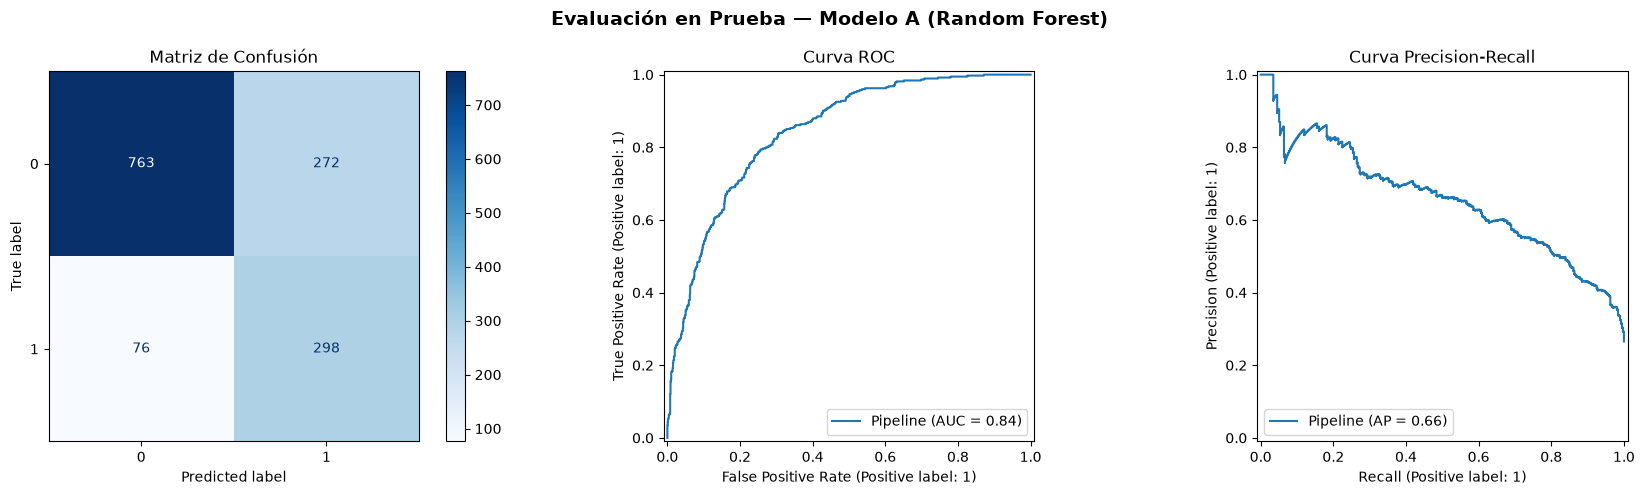

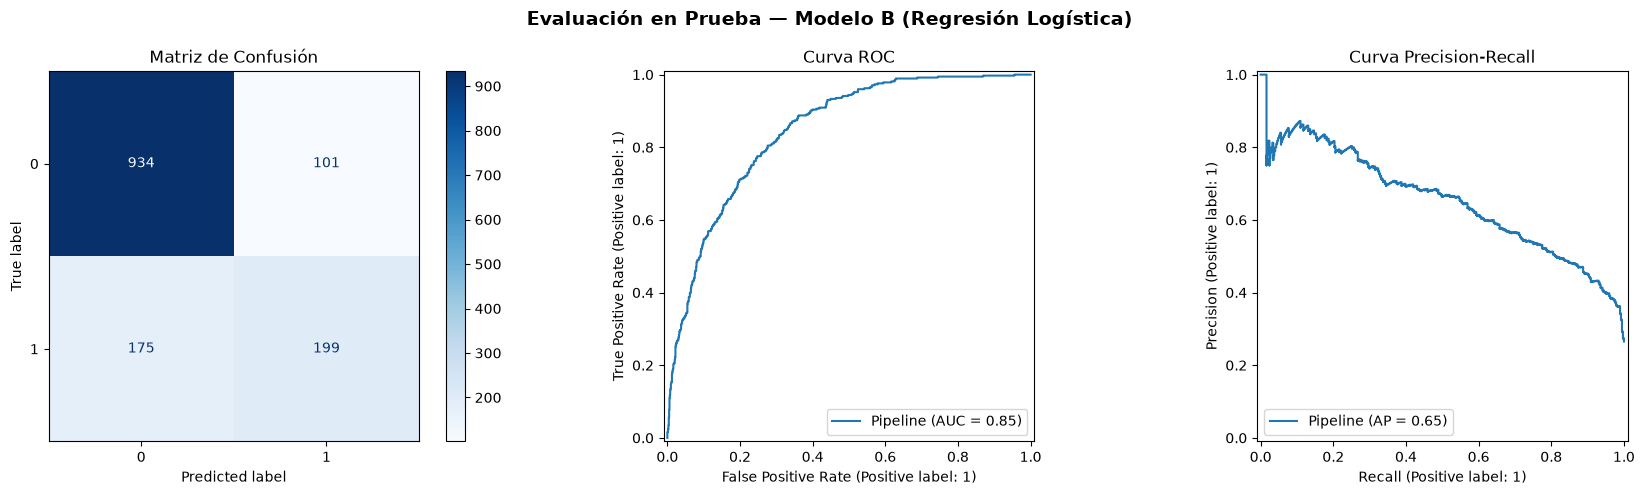


TABLA COMPARATIVA FINAL (CONJUNTO DE PRUEBA)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo finalista,,,,,
Modelo A (Random Forest),0.7530,0.5228,0.7968,0.6314,0.8433
Modelo B (Regresión Logística),0.8041,0.6633,0.5321,0.5905,0.8457


In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperar los modelos finalistas
# Modelo A: Random Forest optimizado mediante GridSearchCV
modelo_a = grid_rf.best_estimator_

# Modelo B: Regresión Logística entrenada con el pipeline maestro
modelo_b = pipe_logreg
modelo_b.fit(X_train, y_train)

# 2. Diccionario para almacenar los resultados en prueba
resultados_prueba = {}
modelos_evaluar = {
    'Modelo A (Random Forest)': modelo_a,
    'Modelo B (Regresión Logística)': modelo_b
}

print("="*65)
print("EVALUACIÓN DE MODELOS FINALISTAS EN EL CONJUNTO DE PRUEBA")
print("="*65)

for nombre, modelo in modelos_evaluar.items():
    # Predicciones discretas y de probabilidad
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    # Cálculo de métricas
    resultados_prueba[nombre] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    
    # Generación de visualizaciones
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Evaluación en Prueba — {nombre}', fontsize=14, fontweight='bold')
    
    # 1. Matriz de Confusión
    ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title('Matriz de Confusión')
    
    # 2. Curva ROC
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=axes[1])
    axes[1].set_title('Curva ROC')
    
    # 3. Curva Precision-Recall
    PrecisionRecallDisplay.from_estimator(modelo, X_test, y_test, ax=axes[2])
    axes[2].set_title('Curva Precision-Recall')
    
    plt.tight_layout()
    plt.show()

# 3. Construcción de la Tabla Comparativa Final (Estructura solicitada / FOTO)
df_tabla_final = pd.DataFrame(resultados_prueba).T
df_tabla_final = df_tabla_final[['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']]
df_tabla_final.index.name = 'Modelo finalista'

print("\n" + "="*65)
print("TABLA COMPARATIVA FINAL (CONJUNTO DE PRUEBA)")
print("="*65)
display(df_tabla_final.round(4))

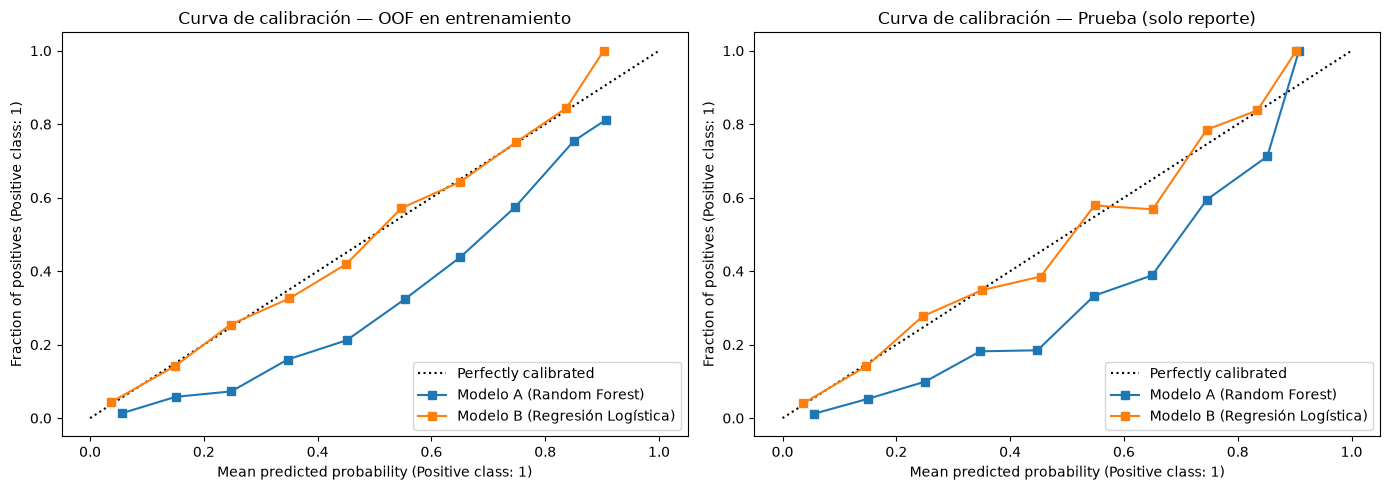

,Brier OOF (entrenamiento),Probabilidad media OOF,Brier prueba (reporte),Probabilidad media prueba
Modelo A (Random Forest),0.1621,0.4153,0.1645,0.4177
Modelo B (Regresión Logística),0.1340,0.2656,0.1362,0.2682


Tasa real de abandono: entrenamiento 0.2654, prueba 0.2654
Brier de referencia (predecir siempre la tasa base): 0.1949


In [17]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import numpy as np

# --- Calibración de probabilidades de los finalistas ---
# Probabilidades fuera de muestra (OOF) en entrenamiento: cada registro se predice con un modelo que no lo vio.
# cross_val_predict no acepta RepeatedStratifiedKFold, por eso se usa StratifiedKFold (5 particiones, semilla 42).
# El conjunto de prueba se muestra solo como reporte.
cv_oof = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
probas_oof = {}
resultados_calibracion = {}

for nombre, modelo in modelos_evaluar.items():
    probas_oof[nombre] = cross_val_predict(modelo, X_train, y_train, cv=cv_oof, method='predict_proba', n_jobs=-1)[:, 1]
    y_proba_prueba = modelo.predict_proba(X_test)[:, 1]
    resultados_calibracion[nombre] = {
        'Brier OOF (entrenamiento)': brier_score_loss(y_train, probas_oof[nombre]),
        'Probabilidad media OOF': probas_oof[nombre].mean(),
        'Brier prueba (reporte)': brier_score_loss(y_test, y_proba_prueba),
        'Probabilidad media prueba': y_proba_prueba.mean()
    }
    CalibrationDisplay.from_predictions(y_train, probas_oof[nombre], n_bins=10, name=nombre, ax=axes[0])
    CalibrationDisplay.from_predictions(y_test, y_proba_prueba, n_bins=10, name=nombre, ax=axes[1])

axes[0].set_title('Curva de calibración — OOF en entrenamiento')
axes[1].set_title('Curva de calibración — Prueba (solo reporte)')
plt.tight_layout()
plt.show()

df_calibracion = pd.DataFrame(resultados_calibracion).T
display(df_calibracion.round(4))
print(f"Tasa real de abandono: entrenamiento {y_train.mean():.4f}, prueba {y_test.mean():.4f}")
print(f"Brier de referencia (predecir siempre la tasa base): {brier_score_loss(y_train, np.full(len(y_train), y_train.mean())):.4f}")

# Probabilidades OOF del Modelo B, usadas para elegir el umbral en el Paso 17
y_proba_oof_b = probas_oof['Modelo B (Regresión Logística)']

**Análisis de la Evaluación en Prueba**

***Confirmación de resultados y Sobreajuste:***

El desempeño de ambos modelos se mantuvo sumamente consistente. El Modelo A (Random Forest) alcanzó un ROC-AUC de 0.8433 en prueba, mientras que el Modelo B (Regresión Logística) logró un 0.8457. Estos valores son prácticamente idénticos a los obtenidos durante la fase de validación cruzada, lo que demuestra una pérdida mínima y confirma que ninguno de los algoritmos sufre de sobreajuste (overfitting).

***Desempeño en las clases:***

Al analizar las matrices de confusión utilizando el umbral predeterminado (0.50), notamos una diferencia de comportamiento. El Modelo A priorizó la detección, logrando identificar a 298 clientes en riesgo (Recall de 0.7968) a costa de generar más falsas alarmas (272 Falsos Positivos). Por el contrario, el Modelo B (Regresión Logística) fue más conservador en este umbral inicial: aunque dejó escapar a 175 clientes reales en riesgo (desplomando su Recall a 0.5321), logró una mejor Precisión (0.6633) y Exactitud (0.8041), cometiendo menos de la mitad de falsas alarmas (solo 101 Falsos Positivos).

***Selección definitiva:***

Aunque en un escenario de retención (Churn) es financieramente prioritario detectar a tiempo a quienes se van a ir (lo que superficialmente daría la victoria al Modelo A), **se selecciona el Modelo B (Regresión Logística)** como el modelo definitivo (también es el finalista con mayor puntaje ponderado en la matriz del Paso 14). La razón analítica es que las probabilidades del Modelo B están bien calibradas: su curva de calibración OOF sigue la diagonal, su Brier OOF es 0.1340 (frente a 0.1621 del Modelo A) y su probabilidad media (0.2656) coincide con la tasa real de abandono (0.2654), mientras que el Random Forest con `class_weight='balanced'` sobreestima el riesgo (probabilidad media 0.4153). Esto nos permite ajustar el umbral operativo (como se abordará en el Paso 17) para elevar su Recall a los niveles necesarios para el negocio. Al hacer esto, obtenemos lo mejor de ambos mundos: la capacidad de detección requerida, sumada a una interpretabilidad total de los coeficientes, menor costo computacional y una facilidad de operación en producción que el Random Forest (al ser un modelo de "caja negra") no puede ofrecer.

# Paso 16: Analizar los errores finales

**Tabla de Ejemplos Representativos de Errores**

Casos reales del conjunto de prueba con el umbral de la evaluación del Paso 15 (0.50); el umbral operativo se define en el Paso 17. Se muestran los errores con mayor confianza del modelo: los falsos positivos con mayor probabilidad y los falsos negativos con menor probabilidad.

In [18]:
# Errores del Modelo B en prueba con el umbral de la evaluación del Paso 15
umbral_evaluacion = 0.50
y_proba_eval = modelo_b.predict_proba(X_test)[:, 1]

df_errores = X_test.assign(
    Clase_real=y_test,
    Prediccion=(y_proba_eval >= umbral_evaluacion).astype(int),
    Probabilidad_Churn=y_proba_eval
)
falsos_positivos = df_errores[(df_errores['Clase_real'] == 0) & (df_errores['Prediccion'] == 1)]
falsos_negativos = df_errores[(df_errores['Clase_real'] == 1) & (df_errores['Prediccion'] == 0)]

casos_error = pd.concat([
    falsos_positivos.nlargest(2, 'Probabilidad_Churn').assign(Tipo_de_error='Falso Positivo (FP)'),
    falsos_negativos.nsmallest(2, 'Probabilidad_Churn').assign(Tipo_de_error='Falso Negativo (FN)')
])
columnas_caso = ['Clase_real', 'Prediccion', 'Probabilidad_Churn', 'Tipo_de_error',
                 'Contract', 'tenure', 'InternetService', 'PaymentMethod', 'MonthlyCharges', 'TechSupport']
display(casos_error[columnas_caso].round(4))

# Perfil agregado de todos los errores, base del análisis cualitativo
perfil_errores = pd.concat([
    falsos_positivos.assign(Tipo='FP'),
    falsos_negativos.assign(Tipo='FN')
]).groupby('Tipo').agg(
    Casos=('tenure', 'size'),
    Tenure_mediano=('tenure', 'median'),
    Pct_mes_a_mes=('Contract', lambda s: (s == 'Month-to-month').mean() * 100),
    Pct_fibra_optica=('InternetService', lambda s: (s == 'Fiber optic').mean() * 100),
    Pct_cheque_electronico=('PaymentMethod', lambda s: (s == 'Electronic check').mean() * 100)
)
display(perfil_errores.round(2))

,Clase_real,Prediccion,Probabilidad_Churn,Tipo_de_error,Contract,tenure,InternetService,PaymentMethod,MonthlyCharges,TechSupport
3346,0,1,0.8688,Falso Positivo (FP),Month-to-month,2,Fiber optic,Electronic check,84.05,No
935,0,1,0.8673,Falso Positivo (FP),Month-to-month,4,Fiber optic,Electronic check,83.25,No
4386,1,0,0.0064,Falso Negativo (FN),Two year,55,DSL,Bank transfer (automatic),57.55,Yes
4513,1,0,0.0121,Falso Negativo (FN),Two year,72,DSL,Credit card (automatic),92.45,Yes


,Casos,Tenure_mediano,Pct_mes_a_mes,Pct_fibra_optica,Pct_cheque_electronico
Tipo,,,,,
FN,175,17.0,74.86,45.71,34.29
FP,101,6.0,100.00,83.17,67.33


**Análisis Cualitativo de los Errores**

#### 1. Patrones compartidos en los casos mal clasificados
* **Falsos Positivos (FP):** El modelo tiende a equivocarse penalizando en exceso a los clientes que tienen contratos mes a mes (`Month-to-month`) y métodos de pago electrónicos (`Electronic check`), presentes en el 100% y el 67% de los FP, respectivamente. Aunque estadísticamente este grupo abandona más, hay una fracción que muestra resistencia al cambio y permanece activa, lo que genera falsas alertas.
* **Falsos Negativos (FN):** La mayoría (75%) tiene contrato mes a mes y antigüedad intermedia (mediana de 17 meses), con probabilidades por debajo de 0.50 que el umbral operativo del Paso 17 recupera en parte. Los FN con mayor confianza del modelo son perfiles que el algoritmo cataloga como "seguros" debido a su alta antigüedad (`tenure`) o contratos de larga duración (`One year` o `Two year`). El error surge porque estos clientes abandonan por factores externos imprevisibles (como mudanza de zona, cambio drástico de tarifas o insatisfacción puntual con el soporte técnico) que no se reflejan en las variables demográficas o de facturación básica.

#### 2. Variables poco representadas o sesgos del modelo
* Las categorías minoritarias en métodos de pago menos comunes o combinaciones atípicas (por ejemplo, clientes con antigüedad muy alta pero con cargos mensuales muy bajos) tienen menor representación, lo que provoca que la Regresión Logística aplique reglas generalistas que fallan en los extremos.

#### 3. Perfiles específicos donde falla el modelo
* **Clientes "Nuevos de alto riesgo aparente":** Aquellos que recién contrataron el servicio pero que, a diferencia de la media que cancela, están dispuestos a mantenerlo a pesar de pagar tarifas elevadas.
* **Clientes "Veteranos inestables":** Usuarios con años de antigüedad que experimentan una ruptura abrupta en su comportamiento de consumo o que sufren un evento de fricción no capturado, sorprendiendo al modelo que confiaba ciegamente en su historial de retención.

#### 4. Acciones recomendadas para reducir estos errores
* **Incorporar variables de interacción o de servicio al cliente:** Integrar métricas sobre el número de reclamaciones o llamadas al soporte técnico (*tech support tickets*), ya que un cliente veterano suele manifestar su descontento por esta vía antes de cancelar.
* **Optimización de umbrales de decisión:** En lugar de usar el umbral predeterminado de 0.50, calibrar un umbral de probabilidad personalizado mediante la curva Precision-Recall para equilibrar el costo de perder un cliente frente al costo operativo de lanzar campañas de retención a Falsos Positivos.
* **Recopilación de datos cualitativos:** Añadir encuestas de salida para entender los motivos de cancelación no monetarios (mudanzas, ofertas de la competencia), reduciendo los Falsos Negativos originados por causas externas al comportamiento digital o de pago.

# Paso 17: Optimizar el umbral de decisión

Umbral óptimo según Índice de Youden: 0.246
Umbral óptimo según F1-score máximo: 0.317
Umbral con Recall >= 0.7: 0.365

Umbral operativo seleccionado: 0.32 (Umbral que maximiza F1 en las probabilidades OOF de entrenamiento (StratifiedKFold 5, semilla 42), redondeado a 2 decimales)

Tabla de umbrales — OOF en entrenamiento:


,Umbral,Precision,Recall,F1-score,Falsos_positivos,Falsos_negativos
0,0.25,0.5137,0.8147,0.6301,1153,277
1,0.30,0.5452,0.7585,0.6344,946,361
2,0.32,0.5610,0.7445,0.6398,871,382
3,0.40,0.6054,0.6609,0.6319,644,507
4,0.50,0.6702,0.5425,0.5996,399,684
5,0.60,0.7215,0.3846,0.5017,222,920
6,0.70,0.7815,0.2368,0.3634,99,1141


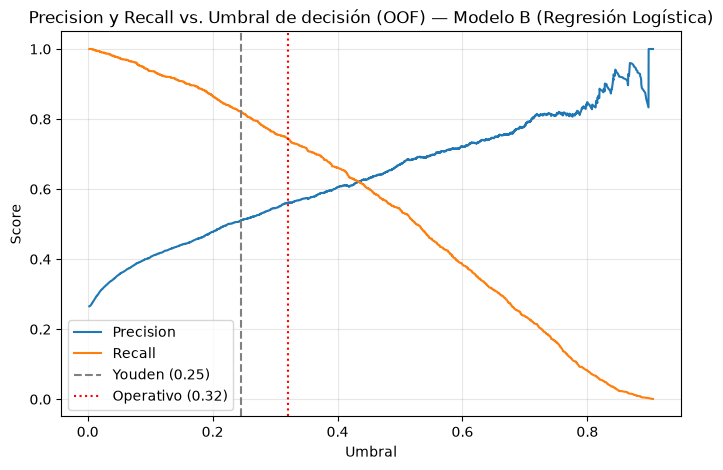

Reporte en prueba — umbral operativo frente al umbral estándar 0.50:


,Umbral,Precision,Recall,F1-score,Falsos_positivos,Falsos_negativos
0,0.32,0.5421,0.7406,0.6260,234,97
1,0.50,0.6633,0.5321,0.5905,101,175


In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import (precision_recall_curve, roc_curve,
                              precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt

# --- Probabilidades OOF del Modelo B en entrenamiento (y_proba_oof_b, calculadas en el Paso 15) ---
# El umbral se elige solo con entrenamiento; el conjunto de prueba se consulta una vez, al final.

# ============================================================
# 1. Evaluación de varios umbrales con distintos criterios (OOF)
# ============================================================
precisions, recalls, thresholds_pr = precision_recall_curve(y_train, y_proba_oof_b)
fpr, tpr, thresholds_roc = roc_curve(y_train, y_proba_oof_b)

# --- Índice de Youden ---
youden_index = tpr - fpr
umbral_youden = thresholds_roc[np.argmax(youden_index)]
print(f"Umbral óptimo según Índice de Youden: {umbral_youden:.3f}")

# --- Umbral que maximiza F1-score ---
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
umbral_f1_max = thresholds_pr[np.argmax(f1_scores[:-1])]
print(f"Umbral óptimo según F1-score máximo: {umbral_f1_max:.3f}")

# --- Umbral con restricción mínima de recall (ej. Recall >= 0.70) ---
recall_minimo = 0.70
idx_validos = np.where(recalls[:-1] >= recall_minimo)[0]
if len(idx_validos) > 0:
    umbral_recall_min = thresholds_pr[idx_validos[-1]]
    print(f"Umbral con Recall >= {recall_minimo}: {umbral_recall_min:.3f}")

# --- Regla de selección del umbral operativo ---
regla_umbral = ("Umbral que maximiza F1 en las probabilidades OOF de entrenamiento "
                "(StratifiedKFold 5, semilla 42), redondeado a 2 decimales")
umbral_operativo = round(float(umbral_f1_max), 2)
print(f"\nUmbral operativo seleccionado: {umbral_operativo:.2f} ({regla_umbral})")

# ============================================================
# 2. Tabla comparativa de umbrales (OOF)
# ============================================================
def tabla_metricas_umbral(y_real, y_proba, umbrales):
    filas = []
    for u in umbrales:
        y_pred_u = (y_proba >= u).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_real, y_pred_u).ravel()
        filas.append({
            'Umbral': u,
            'Precision': round(precision_score(y_real, y_pred_u, zero_division=0), 4),
            'Recall': round(recall_score(y_real, y_pred_u), 4),
            'F1-score': round(f1_score(y_real, y_pred_u), 4),
            'Falsos_positivos': fp,
            'Falsos_negativos': fn
        })
    return pd.DataFrame(filas)

umbrales_a_evaluar = sorted(set([round(float(umbral_youden), 2), umbral_operativo, 0.30, 0.40, 0.50, 0.60, 0.70]))
tabla_umbrales = tabla_metricas_umbral(y_train, y_proba_oof_b, umbrales_a_evaluar)
print("\nTabla de umbrales — OOF en entrenamiento:")
display(tabla_umbrales)

# --- Gráfica Precision-Recall vs Umbral (OOF) ---
plt.figure(figsize=(8,5))
plt.plot(thresholds_pr, precisions[:-1], label='Precision')
plt.plot(thresholds_pr, recalls[:-1], label='Recall')
plt.axvline(x=umbral_youden, color='gray', linestyle='--', label=f'Youden ({umbral_youden:.2f})')
plt.axvline(x=umbral_operativo, color='red', linestyle=':', label=f'Operativo ({umbral_operativo:.2f})')
plt.xlabel('Umbral')
plt.ylabel('Score')
plt.title('Precision y Recall vs. Umbral de decisión (OOF) — Modelo B (Regresión Logística)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 3. Reporte final en prueba (única consulta, con el umbral ya elegido)
# ============================================================
y_proba_b = modelo_b.predict_proba(X_test)[:, 1]
tabla_prueba = tabla_metricas_umbral(y_test, y_proba_b, [umbral_operativo, 0.50])
print("Reporte en prueba — umbral operativo frente al umbral estándar 0.50:")
display(tabla_prueba)

fila_operativa = tabla_prueba.iloc[0]
metricas_operativas = {
    'roc_auc_prueba': round(float(roc_auc_score(y_test, y_proba_b)), 4),
    'recall_prueba': float(fila_operativa['Recall']),
    'precision_prueba': float(fila_operativa['Precision']),
    'f1_prueba': float(fila_operativa['F1-score']),
    'falsos_positivos_prueba': int(fila_operativa['Falsos_positivos']),
    'falsos_negativos_prueba': int(fila_operativa['Falsos_negativos'])
}

Umbral operativo seleccionado 0.32

Regla de selección: umbral que maximiza el F1-score en las probabilidades OOF de entrenamiento (0.317), redondeado a 2 decimales. El conjunto de prueba no se usó para elegirlo, solo para el reporte final.

Objetivo que prioriza: Este umbral prioriza el Recall (0.7406 en prueba) sobre la precision (0.5421), es decir, busca detectar la mayor cantidad posible de clientes que realmente van a abandonar el servicio, aun a costa de generar más falsas alarmas

Costo que reduce: Reduce el costo asociado a los falsos negativos (clientes que se van sin que el modelo los detecte). En un problema de churn, no detectar a un cliente en riesgo significa perder la oportunidad de retenerlo; un costo típicamente mayor que el de una campaña de retención dirigida a alguien que en realidad no iba a irse

Consecuencias que pueden generar: Con este umbral se generan 234 falsos positivos en prueba (clientes marcados como riesgo que en realidad no iban a cancelar). Esto implica un gasto adicional en acciones de retención (descuentos, llamadas, promociones) dirigidas a clientes que no las necesitaban, lo cual reduce la eficiencia de las campañas si no se controla el volumen

Por qué no debe adoptarse sin revisión organizacional: La elección de este umbral asume que el costo de perder un cliente es mayor que el costo de una acción de retención innecesaria, pero esta relación de costos depende del negocio real (margen por cliente, costo de las campañas de retención, capacidad operativa del equipo de retención, etc), información que no está disponible en este análisis. Por eso, antes de operacionalizar este umbral, el equipo de negocio debe validar si esta relación de costos es correcta para el contexto específico de la empresa y ajustar el umbral si es necesario

# Paso 18: Seleccionar el modelo final

### Regresión Logística

In [20]:
from IPython.display import Markdown, display

# Evidencia generada desde las salidas de los Pasos 7 a 17. Los tiempos dependen del equipo de ejecución.
comparacion = df_comparacion_final.drop(index='DummyClassifier')
lr = comparacion.loc['Regresión Logística']
alternativas = comparacion.drop(index='Regresión Logística').sort_values('Métrica media (ROC-AUC)', ascending=False)
mejor_alternativa = alternativas.index[0]
diferencia_auc = lr['Métrica media (ROC-AUC)'] - alternativas.iloc[0]['Métrica media (ROC-AUC)']
cv_lr = resultados_cv['Regresión Logística']

def auc_std(fila):
    return f"{fila['Métrica media (ROC-AUC)']:.4f} ± {fila['Desviación estándar']:.4f}"

def lista_tiempos(columna):
    return "; ".join(f"{nombre} {fila[columna]:.4f} s" for nombre, fila in comparacion.sort_values(columna).iterrows())

evidencia = [
    ('Desempeño',
     f"ROC-AUC en validación cruzada 5x3 (media ± desviación estándar): Regresión Logística {auc_std(lr)}; "
     + "; ".join(f"{nombre} {auc_std(fila)}" for nombre, fila in alternativas.iterrows()) + ".",
     f"Empate en desempeño: la diferencia con la mejor alternativa ({mejor_alternativa}) es {diferencia_auc:+.4f}, "
     f"menor que la desviación estándar entre particiones ({lr['Desviación estándar']:.4f})."),
    ('Generalización',
     f"Desviación estándar del ROC-AUC en validación cruzada: {lr['Desviación estándar']:.4f}. "
     f"ROC-AUC en prueba: {metricas_operativas['roc_auc_prueba']:.4f}.",
     'El desempeño es estable entre particiones y se mantiene en datos no vistos.'),
    ('Errores',
     f"Con umbral 0.50 (validación cruzada): Recall {cv_lr['Recall']:.4f}, Precision {cv_lr['Precision']:.4f}, "
     f"F1 {cv_lr['F1-Score']:.4f}. Con el umbral operativo {umbral_operativo:.2f} (prueba): "
     f"Recall {metricas_operativas['recall_prueba']:.4f}, Precision {metricas_operativas['precision_prueba']:.4f}, "
     f"{metricas_operativas['falsos_negativos_prueba']} FN y {metricas_operativas['falsos_positivos_prueba']} FP.",
     'El Recall bajo con 0.50 se corrige con el umbral operativo del Paso 17, a cambio de más falsos positivos.'),
    ('Interpretabilidad',
     'Coeficientes directos por variable (Paso 19). Random Forest solo ofrece importancia global; SVM RBF y MLP no son interpretables directamente.',
     'Facilita justificar y auditar cada predicción ante los tomadores de decisiones del negocio.'),
    ('Complejidad',
     f"Tiempo medio de entrenamiento por partición: {lista_tiempos('Tiempo de entrenamiento (s)')}.",
     'Menor costo de entrenamiento que los modelos con desempeño equivalente (SVM y modelos optimizados), lo que agiliza el reentrenamiento.'),
    ('Operación',
     f"Tiempo medio de inferencia por partición: {lista_tiempos('Tiempo de inferencia (s)')}.",
     'Baja latencia de inferencia, adecuada para procesos por lotes o en línea.'),
    ('Riesgo',
     'Modelo lineal con regularización L2 por defecto (C=1.0); menor riesgo de sobreajuste que un árbol sin restricciones o un modelo con fronteras de decisión complejas.',
     'Riesgo de sobreajuste controlado: no memoriza el ruido de los datos de entrenamiento.'),
]

tabla_md = "| Criterio | Evidencia | Conclusión |\n| :--- | :--- | :--- |\n"
tabla_md += "\n".join(f"| **{criterio}** | {texto} | {conclusion} |" for criterio, texto, conclusion in evidencia)
display(Markdown(tabla_md))

| Criterio | Evidencia | Conclusión |
| :--- | :--- | :--- |
| **Desempeño** | ROC-AUC en validación cruzada 5x3 (media ± desviación estándar): Regresión Logística 0.8489 ± 0.0116; SVM (Lineal) 0.8475 ± 0.0110; Random Forest (Optimizado) 0.8473 ± 0.0118; SVM RBF (Optimizado) 0.8467 ± 0.0110; MLPClassifier (Opcional) 0.8433 ± 0.0145; SVM (RBF) 0.8289 ± 0.0113; Random Forest (Ensamble) 0.8264 ± 0.0133; Árbol de Decisión 0.8217 ± 0.0144. | Empate en desempeño: la diferencia con la mejor alternativa (SVM (Lineal)) es +0.0014, menor que la desviación estándar entre particiones (0.0116). |
| **Generalización** | Desviación estándar del ROC-AUC en validación cruzada: 0.0116. ROC-AUC en prueba: 0.8457. | El desempeño es estable entre particiones y se mantiene en datos no vistos. |
| **Errores** | Con umbral 0.50 (validación cruzada): Recall 0.5382, Precision 0.6687, F1 0.5956. Con el umbral operativo 0.32 (prueba): Recall 0.7406, Precision 0.5421, 97 FN y 234 FP. | El Recall bajo con 0.50 se corrige con el umbral operativo del Paso 17, a cambio de más falsos positivos. |
| **Interpretabilidad** | Coeficientes directos por variable (Paso 19). Random Forest solo ofrece importancia global; SVM RBF y MLP no son interpretables directamente. | Facilita justificar y auditar cada predicción ante los tomadores de decisiones del negocio. |
| **Complejidad** | Tiempo medio de entrenamiento por partición: Regresión Logística 0.1700 s; Árbol de Decisión 0.2604 s; MLPClassifier (Opcional) 1.1160 s; Random Forest (Ensamble) 1.6832 s; SVM RBF (Optimizado) 1.9704 s; Random Forest (Optimizado) 2.1534 s; SVM (RBF) 2.3729 s; SVM (Lineal) 2.6269 s. | Menor costo de entrenamiento que los modelos con desempeño equivalente (SVM y modelos optimizados), lo que agiliza el reentrenamiento. |
| **Operación** | Tiempo medio de inferencia por partición: Regresión Logística 0.0565 s; MLPClassifier (Opcional) 0.0642 s; Árbol de Decisión 0.0937 s; Random Forest (Optimizado) 0.1580 s; SVM (Lineal) 0.2741 s; Random Forest (Ensamble) 0.4449 s; SVM RBF (Optimizado) 0.7913 s; SVM (RBF) 0.8371 s. | Baja latencia de inferencia, adecuada para procesos por lotes o en línea. |
| **Riesgo** | Modelo lineal con regularización L2 por defecto (C=1.0); menor riesgo de sobreajuste que un árbol sin restricciones o un modelo con fronteras de decisión complejas. | Riesgo de sobreajuste controlado: no memoriza el ruido de los datos de entrenamiento. |

En desempeño hay un empate técnico entre la Regresión Logística, el SVM lineal y los modelos optimizados (Random Forest y SVM RBF). Se elige la Regresión Logística por interpretabilidad y costo operativo; también es el finalista con mayor puntaje en la matriz del Paso 14.

La Regresión Logística permite extraer y auditar los coeficientes matemáticos exactos de cada variable. Esto significa que podemos explicar con precisión cómo factores críticos, como el tipo de contrato, el método de pago o la antigüedad del cliente (tenure), incrementan o reducen la probabilidad de abandono.

Además, al conocer la ecuación exacta de la regresión, es posible construir tableros interactivos que vayan más allá del análisis histórico. Se pueden implementar expresiones DAX avanzadas y parámetros What-If para ver en tiempo real cómo cambiaría la probabilidad de retención de un segmento de clientes si se modifica su oferta actual.

Por último, con tiempos de entrenamiento e inferencia menores que los de los modelos con desempeño equivalente (ver tabla; los tiempos dependen del equipo de ejecución), la Regresión Logística garantiza que el procesamiento de nuevos lotes masivos de datos requiera recursos de cómputo mínimos, reduciendo costos operativos y asegurando que los pipelines de datos se ejecuten sin retrasos.

# Paso 19: Interpretar el modelo globalmente

Ranking de variables por importancia (valor absoluto del coeficiente):
                                     Variable  Coeficiente  \
0                               ord__Contract    -0.743576   
1                          bin__Cliente_Nuevo     0.737669   
2                    nom__InternetService_DSL    -0.720718   
3                                 num__tenure    -0.661389   
4            nom__InternetService_Fiber optic     0.633343   
5                         num__MonthlyCharges    -0.540710   
6                       bin__PaperlessBilling     0.385290   
7        nom__TechSupport_No internet service    -0.303488   
8    nom__StreamingMovies_No internet service    -0.303488   
9        nom__StreamingTV_No internet service    -0.303488   
10    nom__OnlineSecurity_No internet service    -0.303488   
11  nom__DeviceProtection_No internet service    -0.303488   
12      nom__OnlineBackup_No internet service    -0.303488   
13                    nom__InternetService_No    -0.303488   

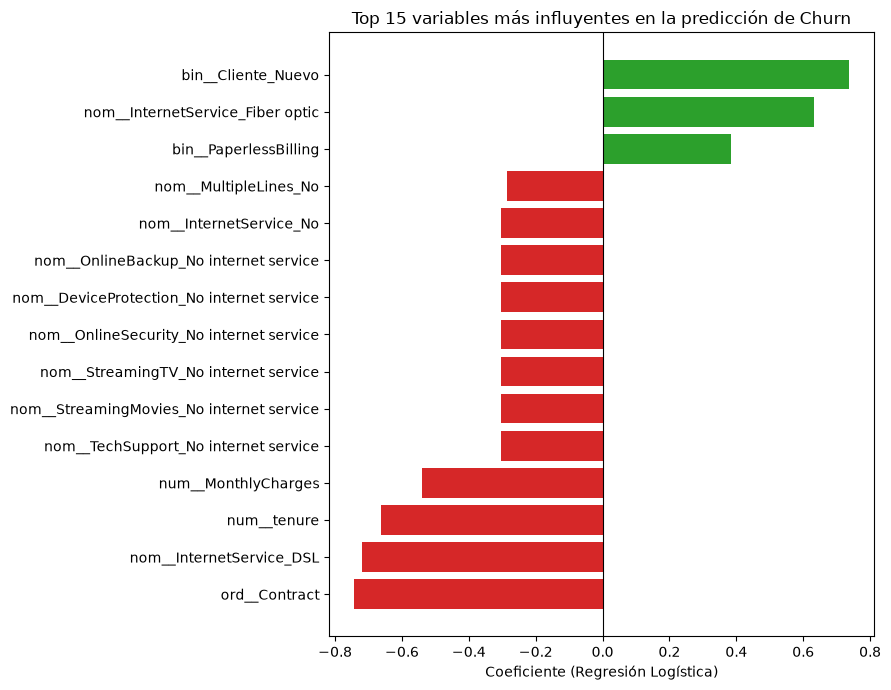

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Extraer nombres de las variables tras el preprocesamiento ---
preprocesador_b = modelo_b.named_steps['preprocesador']
nombres_features = preprocesador_b.get_feature_names_out()

# --- Extraer coeficientes del modelo entrenado ---
coeficientes = modelo_b.named_steps['modelo'].coef_[0]

# --- Armar tabla de ranking ---
df_coef = pd.DataFrame({
    'Variable': nombres_features,
    'Coeficiente': coeficientes,
    'Coeficiente_absoluto': np.abs(coeficientes)
}).sort_values('Coeficiente_absoluto', ascending=False).reset_index(drop=True)

print("Ranking de variables por importancia (valor absoluto del coeficiente):")
print(df_coef.head(15))

# --- Visualización: top 15 variables más influyentes ---
top_n = 15
df_plot = df_coef.head(top_n).sort_values('Coeficiente')

plt.figure(figsize=(9,7))
colores = ['#d62728' if c < 0 else '#2ca02c' for c in df_plot['Coeficiente']]
plt.barh(df_plot['Variable'], df_plot['Coeficiente'], color=colores)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (Regresión Logística)')
plt.title(f'Top {top_n} variables más influyentes en la predicción de Churn')
plt.tight_layout()
plt.show()

Interpretación de los principales factores:

Tipo de contrato(Contract): es el factor más influyente. Como está codificado ordinalmente (Month-to-Month=0, One year=1, Two year=2), un coeficiente negativo significa que entre más largo el contrato, menor la probabilidad de churn, lo cual tiene sentido: clientes con compromisos más largos tienden a quedarse

Cliente nuevo(Cliente_Nuevo): es la segunda variable más influyente, y aumenta el riesgo de churn. Esto es coherente con el patrón típico de negocio: los clientes recién adquiridos son más propensos a cancelar, ya que aun no están afianzados con el servicio

Tipo de internet: tener Fibra óptica aumenta el riesgo de churn, mientras que tener DSL lo reduce. La comparación es entre categorías: el One-Hot conserva todas las categorías (sin `drop`), así que no hay categoría base y solo es interpretable la diferencia entre coeficientes de la misma variable (Fibra óptica − DSL = +1.35). Esto podría deberse a que el servicio de fibra suele ser más caro o tener más problemas percibidos de calidad/precio

Antigüedad(tenure): entre más tiempo lleva el cliente, menor la probabilidad de abandono; un patrón muy esperado y consistente con la lógica de negocio

Cargo mensual(MonthlyCharges): el signo negativo aquí es un poco contraintuitivo(esperaríamos que pagar más se asocie con más churn), y probablemente se debe a colinealidad con otras variables como "InternetService" o "Contract"; el modelo "reparte el efecto entre variables correlacionadas

Detalle notable: todas las variables "_No internet service"(TechSupport, StreamingMovies, StreamingTV, DeviceProtection, OnlineBackup, OnlineSecurity) e `InternetService_No` tienen exactamente el mismo coeficiente (-0.3035). Esto no es casualidad; es un artefacto de colinealidad perfecta: todas esas categorías coinciden exactamente con no tener "InternetService", así que el modelo no puede distinguir su efecto individual

Limitaciones del método:

Los coeficientes de una Regresión Logística asumen una relación log-lineal entre las variables (transformadas) y la probabilidad de churn; no capturan interacciones complejas entre variables ni relaciones no lineales

Son sensibles a la escala de las variables (por eso se estandarizaron las numéricas) y a la colinealidad (como el caso de "No internet service" arriba), lo cual puede distorsionar la magnitud e incluso el signo de un coeficiente

El coeficiente refleja el efecto de la variables controlando por las demás, no su efecto aislado; por eso "MonthlyCharges" puede verse contraintuitivo.

La influencia de una variables en el modelo no implica causalidad; el modelo solo captura asociaciones estadísticas en los datos históricos, no relaciones causa-efecto. Por ejemplo, que "Fibra óptica" se asocie a más churn no significa que la fibra cause el abandono; podría deberse a factores de precio, competencia u otras variables no incluidas

# Paso 20: Explicar predicciones individuales

Calculando valores SHAP para la Regresión Logística...

CASO: Verdadero Positivo (Fuga correctamente detectada)
Probabilidad predicha de Churn: 0.6332 (Umbral de corte: 0.32)
Resultado Real: 1 | Predicción del Modelo: 1


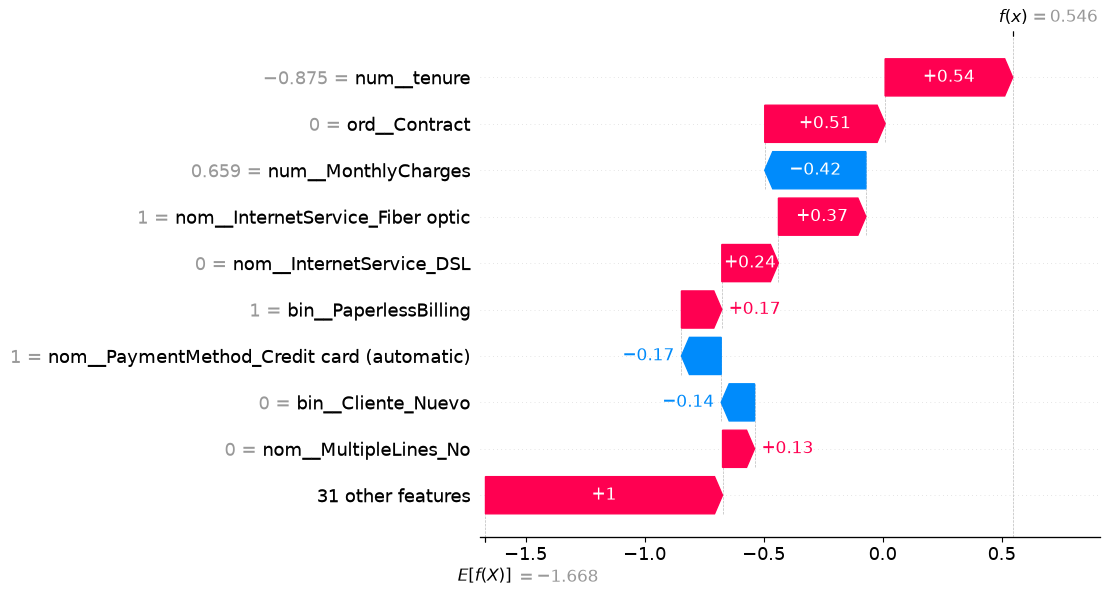


CASO: Verdadero Negativo (Cliente leal correctamente detectado)
Probabilidad predicha de Churn: 0.0443 (Umbral de corte: 0.32)
Resultado Real: 0 | Predicción del Modelo: 0


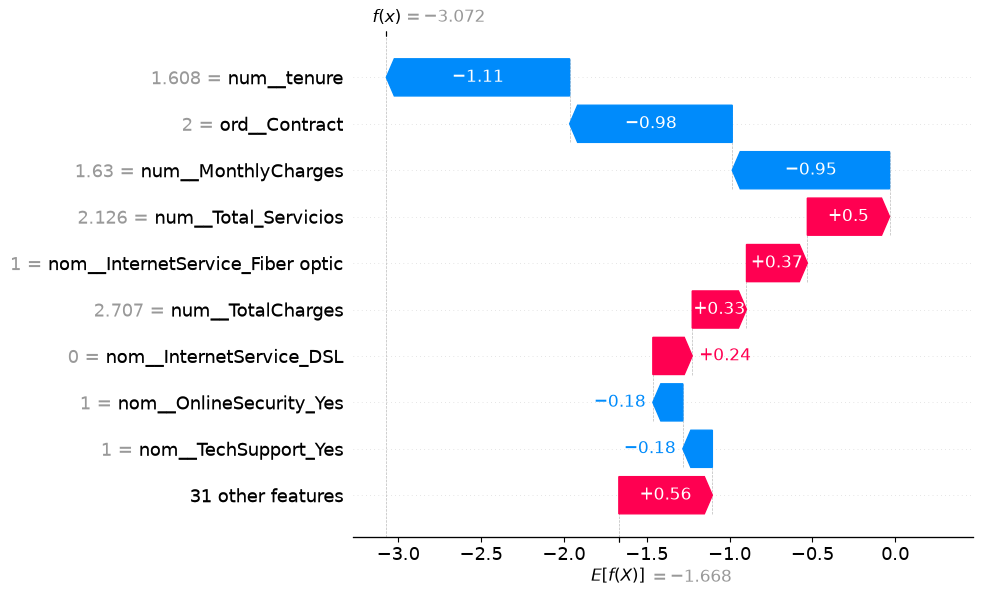


CASO: Falso Positivo (Falsa alarma de fuga)
Probabilidad predicha de Churn: 0.6383 (Umbral de corte: 0.32)
Resultado Real: 0 | Predicción del Modelo: 1


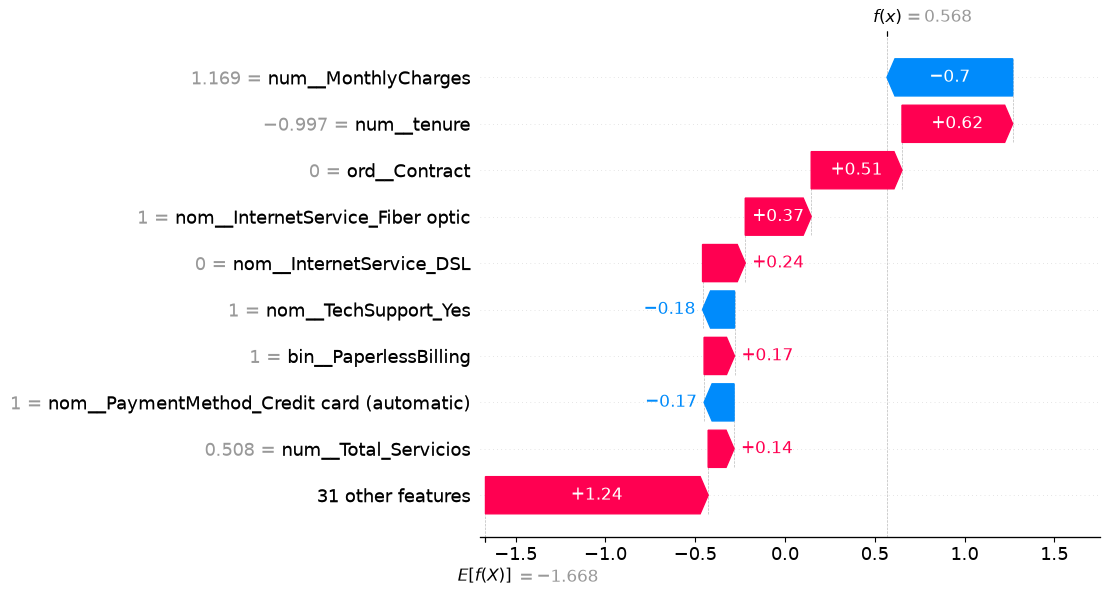


CASO: Falso Negativo (Fuga no detectada)
Probabilidad predicha de Churn: 0.3175 (Umbral de corte: 0.32)
Resultado Real: 1 | Predicción del Modelo: 0


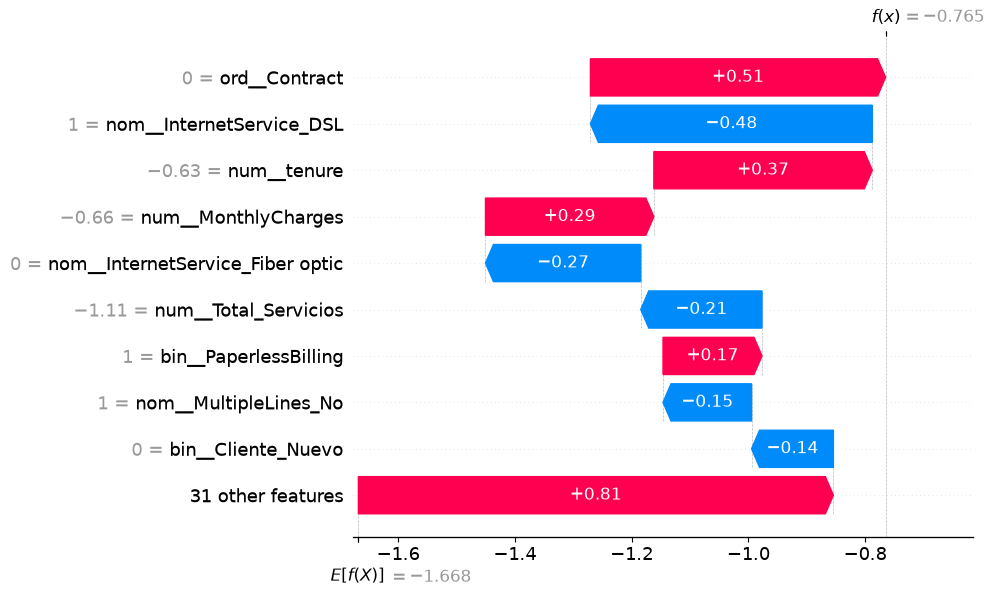

In [22]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Requiere shap (incluido en requirements.txt)

# 1. Obtener predicciones con el umbral operativo elegido en el Paso 17 (umbral_operativo)
y_proba_final = modelo_b.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= umbral_operativo).astype(int)

# 2. Identificar los índices de los 4 casos solicitados (TP, TN, FP, FN)
y_test_arr = np.array(y_test)
idx_tp = np.where((y_test_arr == 1) & (y_pred_final == 1))[0][0] # Verdadero Positivo
idx_tn = np.where((y_test_arr == 0) & (y_pred_final == 0))[0][0] # Verdadero Negativo
idx_fp = np.where((y_test_arr == 0) & (y_pred_final == 1))[0][0] # Falso Positivo
idx_fn = np.where((y_test_arr == 1) & (y_pred_final == 0))[0][0] # Falso Negativo

casos_indices = {
    'Verdadero Positivo (Fuga correctamente detectada)': idx_tp,
    'Verdadero Negativo (Cliente leal correctamente detectado)': idx_tn,
    'Falso Positivo (Falsa alarma de fuga)': idx_fp,
    'Falso Negativo (Fuga no detectada)': idx_fn
}

# 3. Preparar los datos transformados para SHAP
# Extraemos el preprocesador y el modelo final (Regresión Logística)
preprocesador_b = modelo_b.named_steps['preprocesador']
modelo_logreg = modelo_b.named_steps['modelo']
nombres_variables = preprocesador_b.get_feature_names_out()

# Transformamos X_test para que SHAP entienda los números escalados
X_test_prep = preprocesador_b.transform(X_test)
X_test_prep_df = pd.DataFrame(X_test_prep, columns=nombres_variables)

# 4. Configurar SHAP LinearExplainer
print("Calculando valores SHAP para la Regresión Logística...")
explainer = shap.LinearExplainer(modelo_logreg, X_test_prep_df)
shap_values = explainer(X_test_prep_df)

# 5. Generar las explicaciones locales (Waterfall plots) para los 4 casos
for nombre_caso, idx in casos_indices.items():
    print(f"\n{'='*70}")
    print(f"CASO: {nombre_caso}")
    print(f"Probabilidad predicha de Churn: {y_proba_final[idx]:.4f} (Umbral de corte: {umbral_operativo})")
    print(f"Resultado Real: {y_test_arr[idx]} | Predicción del Modelo: {y_pred_final[idx]}")
    print(f"{'='*70}")
    
    # Mostrar la gráfica tipo Cascada (Waterfall)
    plt.figure()
    shap.plots.waterfall(shap_values[idx], max_display=10, show=True)

### Tabla de Predicciones Individuales

| Caso | Resultado real | Predicción | Factores principales (Variables SHAP) | Interpretación (Análisis local) |
| :--- | :--- | :--- | :--- | :--- |
| **Verdadero positivo** | 1 (Canceló) | 1 (Riesgo alto: 0.6332) | **Riesgo (+):** `num__tenure` bajo (+0.54), `ord__Contract` = 0 (+0.51), `nom__InternetService_Fiber optic` = 1 (+0.37).<br>**Retención (-):** `num__MonthlyCharges` alto (-0.42). | El modelo superó el umbral de 0.32 y detectó la fuga porque el cliente tenía contrato mes a mes (`ord__Contract=0`), baja antigüedad (11 meses) y fibra óptica. El cargo mensual alto restaba riesgo (efecto de colinealidad descrito en el Paso 19), pero no alcanzó a compensar esos factores. |
| **Verdadero negativo** | 0 (Se quedó) | 0 (Riesgo bajo: 0.0443) | **Retención (-):** `num__tenure` alto (-1.11), `ord__Contract` = 2 (-0.98), `num__MonthlyCharges` alto (-0.95).<br>**Riesgo (+):** `nom__InternetService_Fiber optic` = 1 (+0.37). | El modelo clasificó al cliente como altamente seguro (solo 4% de riesgo) gracias a su fuerte anclaje: tiene alta antigüedad y un contrato a dos años (`ord__Contract=2`). Estos factores de lealtad aplastaron por completo el ligero riesgo que le generaba tener el servicio de Fibra Óptica. |
| **Falso positivo** | 0 (Se quedó) | 1 (Riesgo alto: 0.6383) | **Riesgo (+):** `num__tenure` muy bajo (+0.62), `ord__Contract` = 0 (+0.51), `nom__InternetService_Fiber optic` = 1 (+0.37). | El modelo generó una fuerte falsa alarma clasificándolo con un 63% de riesgo. Se dejó llevar por el "combo de riesgo" clásico: muy baja antigüedad, contrato mensual y servicio de fibra óptica. El cliente decidió quedarse por factores externos a sus datos demográficos. |
| **Falso negativo** | 1 (Canceló) | 0 (Riesgo bajo: 0.3175) | **Riesgo (+):** `ord__Contract` = 0 (+0.51), `num__tenure` bajo (+0.37).<br>**Retención (-):** `nom__InternetService_DSL` = 1 (-0.48). | La probabilidad quedó justo debajo del umbral de 0.32. El contrato mes a mes y la baja antigüedad (17 meses) empujaban hacia el riesgo, pero tener internet DSL lo compensó. Es un caso cercano al umbral, donde una variación pequeña cambia la clasificación. |

# Paso 21: Evaluar posibles sesgos

Para evaluar posibles sesgos en el modelo, analizaremos el desempeño de la Regresión Logística (utilizando el umbral operativo del Paso 17) segmentando a la población según la antigüedad del cliente (`Cliente_Nuevo`, variable creada en la ingeniería de características), el género (`gender`) y la condición de adulto mayor (`SeniorCitizen`).

Dividiremos el conjunto de prueba en los siguientes grupos:
* **Clientes Nuevos:** Antigüedad $\le$ 6 meses.
* **Clientes Establecidos:** Antigüedad > 6 meses.
* **Mujeres / Hombres** (`gender`).
* **Adultos mayores / No adultos mayores** (`SeniorCitizen` = 1 / 0).

Para cada segmento se calcula también el *Disparate Impact Ratio* (tasa de alertas del grupo entre la tasa de alertas del grupo de referencia), que sirve como línea base para el criterio del Paso 29.

In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Umbral operativo elegido en el Paso 17
umbral = umbral_operativo

# 2. Obtener probabilidades predichas del Modelo B (Regresión Logística) en X_test
y_proba = modelo_b.predict_proba(X_test)[:, 1]
y_pred_umbral = (y_proba >= umbral).astype(int)

# 3. Definir los segmentos; el segundo grupo de cada segmento es la referencia del Disparate Impact Ratio.
# Cliente_Nuevo se obtiene con la misma ingeniería de características del pipeline (Paso 5)
X_test_ing = aplicar_ingenieria_caracteristicas(X_test)
segmentos = {
    'Antigüedad': [
        ('Clientes Nuevos (<= 6 meses)', X_test_ing['Cliente_Nuevo'] == 1),
        ('Clientes Establecidos (> 6 meses)', X_test_ing['Cliente_Nuevo'] == 0)
    ],
    'Género': [
        ('Mujeres', X_test['gender'] == 'Female'),
        ('Hombres', X_test['gender'] == 'Male')
    ],
    'Adulto mayor': [
        ('Adultos mayores (SeniorCitizen = 1)', X_test['SeniorCitizen'] == 1),
        ('No adultos mayores (SeniorCitizen = 0)', X_test['SeniorCitizen'] == 0)
    ]
}

resultados_sesgos = []

# 4. Función para calcular métricas por segmento poblacional
def calcular_metricas_grupo(segmento, nombre_grupo, mascara):
    y_test_grupo = y_test[mascara]
    y_pred_grupo = y_pred_umbral[mascara]

    tn, fp, fn, tp = confusion_matrix(y_test_grupo, y_pred_grupo, labels=[0, 1]).ravel()

    tamaño = len(y_test_grupo)
    tasa_abandono = (y_test_grupo.sum() / tamaño) * 100

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    resultados_sesgos.append({
        'Segmento': segmento,
        'Grupo': nombre_grupo,
        'Tamaño': tamaño,
        'Tasa de abandono (%)': round(tasa_abandono, 2),
        'Tasa de alertas (%)': round(y_pred_grupo.mean() * 100, 2),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'FPR (Tasa Falsos Positivos)': round(fpr, 4),
        'FNR (Tasa Falsos Negativos)': round(fnr, 4)
    })

# 5. Ejecutar los cálculos para todos los grupos
for segmento, grupos in segmentos.items():
    for nombre_grupo, mascara in grupos:
        calcular_metricas_grupo(segmento, nombre_grupo, mascara)

# 6. Mostrar la tabla resultante para el análisis de sesgos
df_sesgos = pd.DataFrame(resultados_sesgos)
display(df_sesgos)

# 7. Disparate Impact Ratio = tasa de alertas del grupo / tasa de alertas del grupo de referencia.
# Rango del Paso 29: [0.80, 1.25]. Estos valores son la línea base del monitoreo.
filas_dir = []
for segmento, ((grupo, mascara), (referencia, mascara_ref)) in segmentos.items():
    tasa_grupo = y_pred_umbral[mascara].mean()
    tasa_referencia = y_pred_umbral[mascara_ref].mean()
    dir_valor = tasa_grupo / tasa_referencia
    filas_dir.append({
        'Segmento': segmento,
        'Grupo': grupo,
        'Referencia': referencia,
        'Tasa de alertas grupo (%)': round(tasa_grupo * 100, 2),
        'Tasa de alertas referencia (%)': round(tasa_referencia * 100, 2),
        'Tasa de abandono real grupo / referencia': round(y_test[mascara].mean() / y_test[mascara_ref].mean(), 4),
        'Disparate Impact Ratio': round(dir_valor, 4),
        'Dentro de [0.80, 1.25]': 0.80 <= dir_valor <= 1.25
    })
df_dir = pd.DataFrame(filas_dir)
display(df_dir)

,Segmento,Grupo,Tamaño,Tasa de abandono (%),Tasa de alertas (%),Precision,Recall,FPR (Tasa Falsos Positivos),FNR (Tasa Falsos Negativos)
0,Antigüedad,Clientes Nuevos (<= 6 meses),311,55.63,72.35,0.6533,0.8497,0.5652,0.1503
1,Antigüedad,Clientes Establecidos (> 6 meses),1098,18.31,26.05,0.4545,0.6468,0.1739,0.3532
2,Género,Mujeres,687,28.09,35.95,0.5628,0.7202,0.2186,0.2798
3,Género,Hombres,722,25.07,36.57,0.5227,0.7624,0.2329,0.2376
4,Adulto mayor,Adultos mayores (SeniorCitizen = 1),222,44.14,63.06,0.6071,0.8673,0.4435,0.1327
5,Adulto mayor,No adultos mayores (SeniorCitizen = 0),1187,23.25,31.26,0.5175,0.6957,0.1965,0.3043


,Segmento,Grupo,Referencia,Tasa de alertas grupo (%),Tasa de alertas referencia (%),Tasa de abandono real grupo / referencia,Disparate Impact Ratio,"Dentro de [0.80, 1.25]"
0,Antigüedad,Clientes Nuevos (<= 6 meses),Clientes Establecidos (> 6 meses),72.35,26.05,3.0387,2.7775,False
1,Género,Mujeres,Hombres,35.95,36.57,1.1206,0.9833,True
2,Adulto mayor,Adultos mayores (SeniorCitizen = 1),No adultos mayores (SeniorCitizen = 0),63.06,31.26,1.8985,2.0177,False


### Análisis de Diferencias y Mitigación

**1. Diferencias observadas:**
Existe una diferencia estadística marcada en el comportamiento del modelo entre ambos grupos. Para los clientes nuevos, el modelo es sumamente agresivo: logra identificar casi todas las fugas reales (*Recall* del 0.8497), pero dispara falsas alarmas en más de la mitad de los que deciden quedarse (FPR de 0.5652). En contraste, con los clientes establecidos, el modelo es mucho más conservador, dejando escapar más de una tercera parte de las fugas reales (FNR de 0.3532).

Por género el desempeño es similar: la tasa de alertas es casi igual (35.95% en mujeres y 36.57% en hombres, *Disparate Impact Ratio* 0.98) y el Recall varía poco (0.7202 frente a 0.7624). Los adultos mayores reciben el doble de alertas que el resto (63.06% frente a 31.26%, *Disparate Impact Ratio* 2.02) y tienen más falsas alarmas (FPR 0.4435 frente a 0.1965). La diferencia sigue a su mayor tasa de abandono (44.14% frente a 23.25%), pero `SeniorCitizen` es una variable demográfica que el modelo usa como entrada, por lo que requiere revisión.

**2. Factores generadores:**
Esta diferencia no obedece a un sesgo discriminatorio injusto, sino a una disparidad en las tasas base de abandono y en la naturaleza del problema. Los clientes nuevos están en un periodo de "prueba" y su probabilidad natural de cancelar es altísima (55.63%). El modelo aprende que ser nuevo es un fuerte predictor de abandono. Por el contrario, un cliente con años de antigüedad tiene una inercia fuerte hacia la retención; cuando cancelan, suele deberse a factores disruptivos (fallas de servicio, mudanzas, ofertas agresivas de la competencia) que no están representados en las variables estáticas de facturación.

**3. Limitaciones del análisis:**
El análisis está limitado por la falta de variables dinámicas de interacción (como tickets de soporte recientes, quejas o uso diario del servicio). Al no tener estos datos, el modelo asume que un cliente veterano siempre será leal basándose únicamente en su historial, lo que infla artificialmente la tasa de Falsos Negativos en ese grupo.

**4. Medidas de revisión y mitigación:**
* **No concluir discriminación:** La diferencia estadística refleja un sesgo algorítmico basado en el ciclo de vida del cliente (antigüedad), no una discriminación ética o demográfica.
* **Línea base del *Disparate Impact Ratio*:** antigüedad 2.78, género 0.98 y adulto mayor 2.02. En antigüedad y adulto mayor el valor ya está fuera de [0.80, 1.25] por la diferencia en tasas de abandono; para esos segmentos el monitoreo del Paso 29 compara contra esta línea base. En género se aplica el rango [0.80, 1.25].
* **Umbrales dinámicos (Mitigación):** Una acción operativa viable es aplicar umbrales de decisión distintos por segmento. Por ejemplo, mantener un umbral estricto para clientes nuevos (para contener el gasto en falsas alarmas) y relajar el umbral aún más para clientes establecidos, asegurando que se capturen las fugas de las cuentas más valiosas.
* **Enriquecimiento de datos:** Incorporar variables temporales recientes (ej. "Llamadas a soporte en los últimos 30 días") para dar al modelo señales tempranas de insatisfacción en clientes veteranos.

# Paso 22: Documentar riesgos y condiciones de uso 

### Registro de riesgos — Modelo B (Regresión Logística, umbral 0.32)

| Riesgo | Causa | Consecuencia | Probabilidad | Impacto | Mitigación |
|---|---|---|---|---|---|
| Falsos negativos | El modelo no detecta a todos los clientes que abandonan (Recall 0.7406; 97 falsos negativos en 1409 registros de prueba, cerca de 1 de cada 4 clientes que se van). | Se pierden clientes sin oportunidad de retención, con pérdida de ingresos recurrentes. | Media | Alto | Usar un umbral bajo (0.32) para priorizar Recall; complementar con reglas de negocio para clientes de alto valor; monitorear el Recall en producción. |
| Falsos positivos | Al bajar el umbral se marcan más clientes como riesgo (Precision 0.5421; 234 falsos positivos, alrededor del 16.6% de los registros de prueba). | Gasto en campañas de retención (descuentos, llamadas) para clientes que no iban a irse; posible saturación del equipo de retención. | Alta | Medio | Priorizar la atención por probabilidad predicha (no tratar a todos igual); limitar el volumen de campañas a la capacidad operativa; medir el costo por retención. |
| Drift | El dataset es una foto histórica; el comportamiento de los clientes, precios y competencia cambian con el tiempo. | El desempeño se degrada sin que nadie lo note y los umbrales dejan de ser válidos. | Media | Alto | Monitorear periódicamente Recall, Precision y la distribución de variables (tenure, MonthlyCharges, Contract); reentrenar y recalibrar el umbral cuando haya degradación. |
| Datos incompletos | `TotalCharges` tenía 11 valores nulos ocultos (clientes con tenure 0) imputados con 0; en producción pueden llegar campos vacíos o categorías nuevas. | Predicciones poco confiables para registros incompletos. | Media | Medio | Mantener la imputación dentro del pipeline; validar el esquema y los nulos antes de predecir; enviar a revisión humana los registros con datos críticos faltantes. |
| Uso automático | Ejecutar acciones (descuentos, cancelaciones, contacto) solo con la salida del modelo, sin supervisión. | Decisiones erróneas a escala, con costos y afectación a clientes, dado que casi la mitad de las alertas serían falsas. | Media | Alto | Usar el modelo solo como apoyo a la decisión, con revisión humana antes de cualquier acción; registrar las decisiones tomadas. |
| Sesgo | El modelo rinde distinto según la antigüedad del cliente. En clientes nuevos (≤ 6 meses, n=311, abandono 55.63%): Recall 0.8497, FPR 0.5652. En establecidos (> 6 meses, n=1098, abandono 18.31%): Recall 0.6468, FNR 0.3532, Precision 0.4545. La diferencia se explica por las distintas tasas base de abandono y por la influencia de `Cliente_Nuevo` en el modelo. Por género el desempeño es similar (*Disparate Impact Ratio* 0.98). Los adultos mayores (n=222, abandono 44.14%) reciben el doble de alertas (*Disparate Impact Ratio* 2.02) con FPR 0.4435 frente a 0.1965. | Más falsas alarmas en clientes nuevos y más abandonos no detectados en clientes establecidos. Más falsas alarmas en adultos mayores, un grupo demográfico. | Media | Alto | Aplicar umbrales por segmento de antigüedad; enriquecer los datos con variables recientes (por ejemplo, llamadas a soporte de los últimos 30 días); monitorear el *Disparate Impact Ratio* por género y `SeniorCitizen` respecto a la línea base del Paso 21; revisión organizacional. |

Usos permitidos
- Identificar clientes con mayor probabilidad de abandono para priorizar campañas de retención.
- Analizar los factores asociados al churn (coeficientes) para apoyar decisiones de negocio.
- Comparar escenarios de umbral según capacidad operativa y costo de retención.

Usos no recomendados
- Tomar decisiones automáticas sobre el cliente (cancelar servicios, negar ofertas, cambiar precios) sin revisión humana.
- Interpretar los coeficientes como relaciones causales.
- Usarlo en poblaciones o mercados distintos a los del dataset, o con datos muy posteriores a los de entrenamiento, sin revalidar.
- Evaluar o sancionar a personas o empleados con base en sus predicciones.

Necesidad de revisión humana
- Toda acción de retención basada en el modelo debe ser validada por el equipo de retención o negocio.
- Se requiere revisión adicional para clientes con datos incompletos o de alto valor.
- El umbral operativo (0.32) requiere validación organizacional de costos antes de adoptarse.

Responsables de supervisión
- Responsable del modelo (científico de datos): monitoreo de métricas y reentrenamiento.
- Responsable de negocio o retención: validación del umbral y de las campañas.
- Responsable de cumplimiento o ética de datos: revisión de sesgos y uso de variables sensibles.

Condiciones para suspender el modelo
- Caída sostenida del Recall o de la Precision respecto a los valores de referencia (Recall 0.7406 y Precision 0.5421 con umbral 0.32), con un límite definido por el equipo.
- Cambios importantes en la distribución de los datos (drift) o en el negocio (nuevos planes, precios o competencia).
- Detección de disparidades relevantes entre subgrupos (antigüedad, género, adultos mayores).
- Aumento de datos incompletos o inconsistentes en la entrada.
- Cambios en la regulación o política de uso de datos personales.

# Paso 23: Serializar el pipeline y el modelo

In [24]:
import hashlib
import json
import platform
import joblib
import sklearn

def calcular_sha256(ruta):
    """Hash SHA-256 del archivo; predictor.py lo verifica antes de joblib.load()."""
    with open(ruta, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()

# 1. Serializar el Pipeline Final Completo (Ingeniería de características + Preprocesamiento + Modelo)
joblib.dump(modelo_b, 'pipeline_final_churn.joblib')

# 2. Serializar el Modelo de forma aislada
modelo_logreg = modelo_b.named_steps['modelo']
joblib.dump(modelo_logreg, 'modelo_logreg_churn.joblib')

# 3. Serializar el umbral operativo (Paso 17) con los metadatos del modelo y el hash de cada artefacto
config_umbral = {
    'version_modelo': 'v1.0',
    'fecha_entrenamiento': FECHA_EJECUCION,
    'version_python': platform.python_version(),
    'version_scikit_learn': sklearn.__version__,
    'variables_entrada': list(X_train.columns),
    'umbral_operativo': umbral_operativo,
    'regla_umbral': regla_umbral,
    'metricas_referencia_prueba': metricas_operativas,
    'sha256': {
        archivo: calcular_sha256(archivo)
        for archivo in ['pipeline_final_churn.joblib', 'modelo_logreg_churn.joblib']
    }
}
with open('umbral_churn.json', 'w', encoding='utf-8') as f:
    json.dump(config_umbral, f, indent=2, ensure_ascii=False)

print("✅ Artefactos serializados correctamente en el directorio de trabajo.")
print(json.dumps(config_umbral, indent=2, ensure_ascii=False))

✅ Artefactos serializados correctamente en el directorio de trabajo.
{
  "version_modelo": "v1.0",
  "fecha_entrenamiento": "2026-09-30",
  "version_python": "3.11.11",
  "version_scikit_learn": "1.9.1",
  "variables_entrada": [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges"
  ],
  "umbral_operativo": 0.32,
  "regla_umbral": "Umbral que maximiza F1 en las probabilidades OOF de entrenamiento (StratifiedKFold 5, semilla 42), redondeado a 2 decimales",
  "metricas_referencia_prueba": {
    "roc_auc_prueba": 0.8457,
    "recall_prueba": 0.7406,
    "precision_prueba": 0.5421,
    "f1_prueba": 0.626,
    "falsos_positivos_prueba": 234,
    "falsos_negativos_prueba": 97

## Paso 23: Serialización del modelo

A continuación se documentan los artefactos generados para el despliegue del modelo de predicción de abandono (Churn).

| Artefacto | Archivo | Versión | Fecha | Biblioteca |
| :--- | :--- | :--- | :--- | :--- |
| **Pipeline final** | `pipeline_final_churn.joblib` | v1.0 | 2026-09-30 | `joblib` (scikit-learn) |
| **Modelo** | `modelo_logreg_churn.joblib` | v1.0 | 2026-09-30 | `joblib` (scikit-learn) |
| **Codificación de objetivo** | *N/A (Nativa)* | N/A | 2026-09-30 | *Variable binaria directa (0/1)* |
| **Umbral, metadatos y hash SHA-256** | `umbral_churn.json` | v1.0 | 2026-09-30 | `json` (Python Standard Library) |

> ⚠️ **ADVERTENCIA DE SEGURIDAD:**
> Los archivos serializados generados con `joblib` o `pickle` pueden contener código ejecutable malicioso. Al usar funciones como `joblib.load()`, el entorno de Python ejecuta las instrucciones de reconstrucción del objeto sin ninguna restricción. **Nunca** cargues ni deserialices archivos `.joblib`, `.pkl` o similares que provengan de fuentes desconocidas, correos electrónicos no verificados o repositorios de terceros sin auditar, ya que esto podría comprometer por completo la seguridad del sistema anfitrión.
>
> `cargar_artefactos()` (Paso 24) verifica el hash SHA-256 registrado en `umbral_churn.json` antes de `joblib.load()`. El JSON debe resguardarse con el mismo control de acceso que los `.joblib`.

## Paso 24: Script de Inferencia y Validación Independiente para Predicción de Churn



In [25]:
%%writefile predictor.py
"""Inferencia del modelo de churn (Pasos 24 a 26).

CÓMO USARLO
1. Instalar dependencias:  pip install -r requirements.txt
2. Generar el modelo:      ejecutar proyecto_final.ipynb (crea pipeline_final_churn.joblib y umbral_churn.json)
3. Predecir:               python predictor.py cliente_ejemplo.json

Entrada: archivo JSON con un cliente (objeto) o varios (lista de objetos) con las 19 columnas
de COLUMNAS_REQUERIDAS. En la misma carpeta deben estar ingenieria_caracteristicas.py,
pipeline_final_churn.joblib y umbral_churn.json.

Salida por cliente: probabilidad, clasificación, umbral, versión del modelo y aviso de revisión humana.
Los registros con datos inválidos no se predicen: se envían a revisión humana con el motivo.

Ejemplos de cliente_ejemplo.json:
  Registro 0: 2 meses, contrato mes a mes, fibra óptica      -> 75.04%, Abandono (Churn)
  Registro 1: 60 meses, contrato a dos años, DSL             -> 0.73%, No abandono
  Registro 2: método de pago no reconocido ("Digital wallet") -> revisión humana, sin predicción

Desde Python:
  from predictor import leer_entrada, predecir_nuevos_registros
  resultados, reporte = predecir_nuevos_registros(leer_entrada('cliente_ejemplo.json'))
"""
import argparse
import hashlib
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

CARPETA = Path(__file__).resolve().parent
RUTA_PIPELINE = CARPETA / 'pipeline_final_churn.joblib'
RUTA_CONFIG = CARPETA / 'umbral_churn.json'
AVISO = ('El resultado mostrado es una estimación basada en un modelo estadístico '
         'y requiere revisión humana para la toma de decisiones.')

COLUMNAS_REQUERIDAS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges'
]
COLUMNAS_NUMERICAS = ['tenure', 'MonthlyCharges', 'TotalCharges']
SERVICIO_INTERNET = ['No', 'Yes', 'No internet service']
CATEGORIAS_VALIDAS = {
    'gender': ['Female', 'Male'],
    'SeniorCitizen': [0, 1],
    'Partner': ['Yes', 'No'],
    'Dependents': ['Yes', 'No'],
    'PhoneService': ['Yes', 'No'],
    'MultipleLines': ['No phone service', 'No', 'Yes'],
    'InternetService': ['DSL', 'Fiber optic', 'No'],
    'OnlineSecurity': SERVICIO_INTERNET,
    'OnlineBackup': SERVICIO_INTERNET,
    'DeviceProtection': SERVICIO_INTERNET,
    'TechSupport': SERVICIO_INTERNET,
    'StreamingTV': SERVICIO_INTERNET,
    'StreamingMovies': SERVICIO_INTERNET,
    'Contract': ['Month-to-month', 'One year', 'Two year'],
    'PaperlessBilling': ['Yes', 'No'],
    'PaymentMethod': ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
}


def calcular_sha256(ruta):
    with open(ruta, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()


def cargar_artefactos():
    """Carga la configuración, verifica el hash SHA-256 del pipeline y solo entonces lo deserializa."""
    with open(RUTA_CONFIG, 'r', encoding='utf-8') as f:
        config = json.load(f)
    if calcular_sha256(RUTA_PIPELINE) != config['sha256'][RUTA_PIPELINE.name]:
        raise ValueError(f"El hash SHA-256 de '{RUTA_PIPELINE.name}' no coincide con el registrado; no se carga el archivo.")
    pipeline = joblib.load(RUTA_PIPELINE)
    return pipeline, config


def validar_datos_entrada(df):
    """
    Valida los datos de entrada recopilando anomalías sin detener la ejecución.
    Detecta: campos faltantes, tipos incorrectos, valores nulos, valores fuera de rango,
    categorías no reconocidas, columnas adicionales y estructura incompleta.
    'motivos_por_registro' lista los registros que deben ir a revisión humana en lugar de predecirse.
    Se permiten nulos en TotalCharges (clientes con tenure = 0) y en las categóricas: el pipeline los imputa.
    """
    reporte = {
        "valido": True,
        "campos_faltantes": [],
        "columnas_adicionales": [],
        "tipos_incorrectos": [],
        "valores_nulos": [],
        "valores_fuera_de_rango": [],
        "categorias_no_reconocidas": [],
        "motivos_por_registro": {}
    }
    motivos = {idx: [] for idx in df.index}

    def registrar(clave, mascara, mensaje):
        """Agrega el hallazgo al reporte general y a cada registro afectado."""
        mascara = np.asarray(mascara, dtype=bool)
        if mascara.any():
            reporte[clave].append(f"{mensaje}: {mascara.sum()} registros.")
            for idx in df.index[mascara]:
                motivos[idx].append(mensaje)

    # 1. Estructura incompleta y columnas adicionales
    faltantes = [col for col in COLUMNAS_REQUERIDAS if col not in df.columns]
    reporte["columnas_adicionales"] = [col for col in df.columns if col not in COLUMNAS_REQUERIDAS]
    if faltantes:
        reporte["campos_faltantes"] = faltantes
        for idx in df.index:
            motivos[idx].append(f"Faltan columnas requeridas: {faltantes}")

    # 2. Tipos incorrectos, nulos y valores fuera de rango en numéricas
    for col in [c for c in COLUMNAS_NUMERICAS if c in df.columns]:
        valores = df[col].replace(r'^\s*$', np.nan, regex=True)
        numerico = pd.to_numeric(valores, errors='coerce')
        registrar("tipos_incorrectos", numerico.isna() & valores.notna(), f"'{col}' no es numérico")
        if col != 'TotalCharges':
            registrar("valores_nulos", valores.isna(), f"'{col}' vacío")
    if 'tenure' in df.columns:
        tenure = pd.to_numeric(df['tenure'], errors='coerce')
        registrar("valores_fuera_de_rango", (tenure < 0) | (tenure > 72), "'tenure' fuera del rango [0, 72]")
    if 'MonthlyCharges' in df.columns:
        cargos = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
        registrar("valores_fuera_de_rango", cargos <= 0, "'MonthlyCharges' con valores <= 0")
    if 'TotalCharges' in df.columns:
        total = pd.to_numeric(df['TotalCharges'], errors='coerce')
        registrar("valores_fuera_de_rango", total < 0, "'TotalCharges' con valores negativos")

    # 3. Categorías no reconocidas en todas las variables categóricas y binarias
    for col, validas in CATEGORIAS_VALIDAS.items():
        if col in df.columns:
            invalidas = df[col].notna() & ~df[col].isin(validas)
            if invalidas.any():
                reporte["categorias_no_reconocidas"].append(
                    f"'{col}' tiene categorías no válidas: {list(df.loc[invalidas, col].unique())}")
                for idx in df.index[invalidas.to_numpy()]:
                    motivos[idx].append(f"'{col}' con categoría no reconocida")

    reporte["motivos_por_registro"] = {idx: m for idx, m in motivos.items() if m}
    reporte["valido"] = not reporte["motivos_por_registro"]
    return reporte


def predecir_nuevos_registros(df_nuevos):
    """Valida, predice los registros válidos y marca los inválidos para revisión humana."""
    pipeline, config = cargar_artefactos()
    umbral = config['umbral_operativo']
    reporte = validar_datos_entrada(df_nuevos)
    validos = ~df_nuevos.index.isin(list(reporte['motivos_por_registro']))

    resultados = pd.DataFrame(index=df_nuevos.index)
    resultados['Probabilidad_Churn'] = np.nan
    resultados['Clase_Predicha'] = pd.Series(pd.NA, index=df_nuevos.index, dtype='Int64')
    resultados['Decision'] = 'Revisión humana: datos inválidos'
    if validos.any():
        df_validos = df_nuevos.loc[validos, COLUMNAS_REQUERIDAS].copy()
        df_validos[COLUMNAS_NUMERICAS] = (df_validos[COLUMNAS_NUMERICAS]
                                          .replace(r'^\s*$', np.nan, regex=True)
                                          .apply(pd.to_numeric))
        y_proba = pipeline.predict_proba(df_validos)[:, 1]
        y_pred = (y_proba >= umbral).astype(int)
        resultados.loc[validos, 'Probabilidad_Churn'] = y_proba
        resultados.loc[validos, 'Clase_Predicha'] = y_pred
        resultados.loc[validos, 'Decision'] = np.where(y_pred == 1, 'Alerta de Abandono (Churn)', 'Cliente Retenido')
    resultados['Umbral'] = umbral
    resultados['Version_Modelo'] = f"{config['version_modelo']} ({config['fecha_entrenamiento']})"
    return resultados, reporte


def leer_entrada(ruta_json):
    """Lee un registro (objeto JSON) o varios (lista de objetos) como DataFrame."""
    with open(ruta_json, 'r', encoding='utf-8') as f:
        datos = json.load(f)
    return pd.DataFrame(datos if isinstance(datos, list) else [datos])


def imprimir_resultados(resultados, reporte):
    for idx, fila in resultados.iterrows():
        print("--- RESULTADO DE LA INFERENCIA ---")
        if idx in reporte['motivos_por_registro']:
            print(f"Registro {idx}: enviado a revisión humana sin predicción")
            print(f"Motivos: {'; '.join(reporte['motivos_por_registro'][idx])}")
        else:
            clasificacion = 'Abandono (Churn)' if fila['Clase_Predicha'] == 1 else 'No abandono'
            print(f"Probabilidad estimada de abandono: {fila['Probabilidad_Churn']:.2%}")
            print(f"Clasificación resultante: {clasificacion}")
        print(f"Umbral utilizado: {fila['Umbral']:.2f}")
        print(f"Fecha / Versión del modelo: {fila['Version_Modelo']}")
        print(f"Aviso: {AVISO}")
        print("----------------------------------")


def main():
    parser = argparse.ArgumentParser(description='Predicción de abandono de clientes (churn).')
    parser.add_argument('entrada', help='Archivo JSON con un registro o una lista de registros')
    args = parser.parse_args()
    resultados, reporte = predecir_nuevos_registros(leer_entrada(args.entrada))
    imprimir_resultados(resultados, reporte)


if __name__ == "__main__":
    main()

Overwriting predictor.py


In [26]:
import importlib
import predictor
importlib.reload(predictor)  # toma la versión de predictor.py escrita en la celda anterior

# Ejemplos documentados en cliente_ejemplo.json: alerta de churn, sin alerta y registro inválido (también se usan en el Paso 25)
cliente_ejemplo = predictor.leer_entrada('cliente_ejemplo.json')
resultados_ejemplo, reporte_ejemplo = predictor.predecir_nuevos_registros(cliente_ejemplo)
print("Resultado de la predicción:")
display(resultados_ejemplo)

Resultado de la predicción:


,Probabilidad_Churn,Clase_Predicha,Decision,Umbral,Version_Modelo
0,0.750408,1,Alerta de Abandono (Churn),0.32,v1.0 (2026-09-30)
1,0.007282,0,Cliente Retenido,0.32,v1.0 (2026-09-30)
2,NaN,<NA>,Revisión humana: datos inválidos,0.32,v1.0 (2026-09-30)


# Paso 25: Implementar un mecanismo mínimo de inferencia

Se creó un script ejecutable desde la consola o terminal (`predictor.py`, generado en el Paso 24) usando el siguiente comando de Powershell:

**python predictor.py cliente_ejemplo.json**

La información que recibe del cliente es mediante un formato estructurado (JSON).

El script verifica el hash SHA-256 del modelo, carga el pipeline (pipeline_final_churn.joblib), valida los datos recibidos, aplica las transformaciones necesarias y entrega la predicción correspondiente. Los registros inválidos se envían a revisión humana en lugar de predecirse.

Ejemplo de salida (mismos clientes del Paso 24):

In [27]:
import os
import subprocess
import sys

# Ejecución del script desde la terminal con los ejemplos del Paso 24
salida = subprocess.run(
    [sys.executable, 'predictor.py', 'cliente_ejemplo.json'],
    capture_output=True, text=True, encoding='utf-8',
    env={**os.environ, 'PYTHONIOENCODING': 'utf-8'}
)
print(salida.stdout or salida.stderr)

--- RESULTADO DE LA INFERENCIA ---
Probabilidad estimada de abandono: 75.04%
Clasificación resultante: Abandono (Churn)
Umbral utilizado: 0.32
Fecha / Versión del modelo: v1.0 (2026-09-30)
Aviso: El resultado mostrado es una estimación basada en un modelo estadístico y requiere revisión humana para la toma de decisiones.
----------------------------------
--- RESULTADO DE LA INFERENCIA ---
Probabilidad estimada de abandono: 0.73%
Clasificación resultante: No abandono
Umbral utilizado: 0.32
Fecha / Versión del modelo: v1.0 (2026-09-30)
Aviso: El resultado mostrado es una estimación basada en un modelo estadístico y requiere revisión humana para la toma de decisiones.
----------------------------------
--- RESULTADO DE LA INFERENCIA ---
Registro 2: enviado a revisión humana sin predicción
Motivos: 'PaymentMethod' con categoría no reconocida
Umbral utilizado: 0.32
Fecha / Versión del modelo: v1.0 (2026-09-30)
Aviso: El resultado mostrado es una estimación basada en un modelo estadístico y

# Paso 26: Implementación de Controles de Validación y Calidad de Datos

In [28]:
# validar_datos_entrada() está definida en predictor.py (Paso 24) y se invoca dentro de
# predecir_nuevos_registros(): los registros inválidos se marcan para revisión humana en lugar de predecirse.
from predictor import validar_datos_entrada

# 1. Dataset completo (customerID y Churn se reportan como columnas adicionales)
reporte = validar_datos_entrada(df)
print({clave: valor for clave, valor in reporte.items() if clave != 'motivos_por_registro'})

# 2. Registros con errores de ejemplo, a partir del primer cliente del Paso 24
ejemplo = cliente_ejemplo.iloc[0].to_dict()
registros_prueba = pd.DataFrame([
    ejemplo,                                   # válido
    {**ejemplo, 'tenure': 90},                 # fuera de rango
    {**ejemplo, 'PaymentMethod': 'Crypto'},    # categoría no reconocida
    {**ejemplo, 'MonthlyCharges': 'abc'},      # tipo incorrecto
    {**ejemplo, 'SeniorCitizen': 2},           # valor binario no válido
])
resultados_validacion, reporte_validacion = predictor.predecir_nuevos_registros(registros_prueba)
display(resultados_validacion)
for idx, motivos in reporte_validacion['motivos_por_registro'].items():
    print(f"Registro {idx}: {'; '.join(motivos)}")

{'valido': True, 'campos_faltantes': [], 'columnas_adicionales': ['customerID', 'Churn'], 'tipos_incorrectos': [], 'valores_nulos': [], 'valores_fuera_de_rango': [], 'categorias_no_reconocidas': []}


,Probabilidad_Churn,Clase_Predicha,Decision,Umbral,Version_Modelo
0,0.750408,1,Alerta de Abandono (Churn),0.32,v1.0 (2026-09-30)
1,NaN,<NA>,Revisión humana: datos inválidos,0.32,v1.0 (2026-09-30)
2,NaN,<NA>,Revisión humana: datos inválidos,0.32,v1.0 (2026-09-30)
3,NaN,<NA>,Revisión humana: datos inválidos,0.32,v1.0 (2026-09-30)
4,NaN,<NA>,Revisión humana: datos inválidos,0.32,v1.0 (2026-09-30)


Registro 1: 'tenure' fuera del rango [0, 72]
Registro 2: 'PaymentMethod' con categoría no reconocida
Registro 3: 'MonthlyCharges' no es numérico
Registro 4: 'SeniorCitizen' con categoría no reconocida


# Paso 27: Evaluación de Perfiles de Riesgo y Proceso de Revisión Humana

In [29]:
from IPython.display import Markdown, display

# Bandas de riesgo coherentes con el umbral operativo del Paso 17:
#   Bajo: p < umbral (sin alerta) | Medio: umbral <= p < 0.50 (alerta) | Alto: p >= 0.50 (alerta)
def banda_riesgo(p):
    if p < umbral_operativo:
        return f'Bajo (< {umbral_operativo:.2f})'
    if p < 0.50:
        return f'Medio ({umbral_operativo:.2f} a 0.50)'
    return 'Alto (≥ 0.50)'

# Probabilidades en prueba del Paso 20
df_perfiles = X_test.assign(Probabilidad=y_proba_final)
df_perfiles['Banda'] = df_perfiles['Probabilidad'].apply(banda_riesgo)

def caso_mediano(mascara):
    """Registro cuya probabilidad es la mediana de la banda."""
    probabilidades = df_perfiles.loc[mascara, 'Probabilidad']
    return (probabilidades - probabilidades.median()).abs().idxmin()

# Categoría menos frecuente en entrenamiento (desempate: mayor probabilidad)
cols_categoricas = [c for c in X_train.columns if c not in ['tenure', 'MonthlyCharges', 'TotalCharges']]
frecuencias = {c: X_train[c].value_counts(normalize=True) for c in cols_categoricas}
frecuencia_minima = pd.DataFrame({c: X_test[c].map(frecuencias[c]) for c in cols_categoricas}).min(axis=1)
idx_poco_frecuente = df_perfiles.loc[frecuencia_minima == frecuencia_minima.min(), 'Probabilidad'].idxmax()

casos_perfil = [
    ('Cliente con bajo riesgo', caso_mediano(df_perfiles['Probabilidad'] < umbral_operativo),
     'Cliente sin alerta; no requiere intervención comercial proactiva.'),
    ('Cliente con riesgo medio', caso_mediano(df_perfiles['Probabilidad'].between(umbral_operativo, 0.50, inclusive='left')),
     'Genera alerta; revisar su historial reciente antes de ofrecer una acción preventiva.'),
    ('Cliente con alto riesgo', caso_mediano(df_perfiles['Probabilidad'] >= 0.50),
     'Candidato prioritario para una campaña de retención y asignación de un ejecutivo de cuenta.'),
    ('Caso con categoría poco frecuente', idx_poco_frecuente,
     'Requiere supervisión analítica para verificar si la categoría atípica está distorsionando el riesgo.'),
    ('Caso cercano al umbral', (df_perfiles['Probabilidad'] - umbral_operativo).abs().idxmin(),
     'Una pequeña variación en las variables cambia la clasificación; requiere doble validación humana.'),
]

filas = []
for nombre, idx, observacion in casos_perfil:
    fila = df_perfiles.loc[idx]
    contribuciones = pd.Series(shap_values[X_test.index.get_loc(idx)].values, index=nombres_variables)
    principales = contribuciones.reindex(contribuciones.abs().sort_values(ascending=False).index[:3])
    factores = '<br>'.join(f"`{variable}` ({valor:+.2f})" for variable, valor in principales.items())
    perfil = f"{fila['Contract']}, tenure {fila['tenure']} {'mes' if fila['tenure'] == 1 else 'meses'}, {fila['InternetService']}, {fila['PaymentMethod']}"
    if nombre == 'Caso con categoría poco frecuente':
        col_rara = min(cols_categoricas, key=lambda c: frecuencias[c][fila[c]])
        perfil += f"<br>Categoría poco frecuente: `{col_rara}` = {fila[col_rara]} ({frecuencias[col_rara][fila[col_rara]]:.1%} del entrenamiento)"
    clasificacion = 'Churn (alerta)' if fila['Probabilidad'] >= umbral_operativo else 'No Churn'
    filas.append(f"| **{nombre}** | {fila['Probabilidad']:.4f} | {fila['Banda']} | {clasificacion} | {perfil} | {factores} | {observacion} |")

tabla_md = ("| Cliente | Probabilidad | Banda | Clasificación | Perfil | Factores principales (SHAP) | Observación |\n"
            "| :--- | :--- | :--- | :--- | :--- | :--- | :--- |\n" + "\n".join(filas))
display(Markdown(tabla_md))

| Cliente | Probabilidad | Banda | Clasificación | Perfil | Factores principales (SHAP) | Observación |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Cliente con bajo riesgo** | 0.0682 | Bajo (< 0.32) | No Churn | Two year, tenure 72 meses, Fiber optic, Credit card (automatic) | `num__tenure` (-1.11)<br>`ord__Contract` (-0.98)<br>`num__MonthlyCharges` (-0.42) | Cliente sin alerta; no requiere intervención comercial proactiva. |
| **Cliente con riesgo medio** | 0.4158 | Medio (0.32 a 0.50) | Churn (alerta) | Month-to-month, tenure 1 mes, DSL, Electronic check | `num__tenure` (+0.80)<br>`bin__Cliente_Nuevo` (+0.60)<br>`ord__Contract` (+0.51) | Genera alerta; revisar su historial reciente antes de ofrecer una acción preventiva. |
| **Cliente con alto riesgo** | 0.6645 | Alto (≥ 0.50) | Churn (alerta) | Month-to-month, tenure 3 meses, Fiber optic, Bank transfer (automatic) | `num__tenure` (+0.75)<br>`bin__Cliente_Nuevo` (+0.60)<br>`ord__Contract` (+0.51) | Candidato prioritario para una campaña de retención y asignación de un ejecutivo de cuenta. |
| **Caso con categoría poco frecuente** | 0.7752 | Alto (≥ 0.50) | Churn (alerta) | Month-to-month, tenure 4 meses, DSL, Electronic check<br>Categoría poco frecuente: `PhoneService` = No (9.9% del entrenamiento) | `num__tenure` (+0.72)<br>`bin__Cliente_Nuevo` (+0.60)<br>`ord__Contract` (+0.51) | Requiere supervisión analítica para verificar si la categoría atípica está distorsionando el riesgo. |
| **Caso cercano al umbral** | 0.3192 | Bajo (< 0.32) | No Churn | Month-to-month, tenure 11 meses, DSL, Electronic check | `num__tenure` (+0.54)<br>`ord__Contract` (+0.51)<br>`nom__InternetService_DSL` (-0.48) | Una pequeña variación en las variables cambia la clasificación; requiere doble validación humana. |

Proceso de Revisión Humana y Decisiones No Automatizadas
1. Uso operativo de cada resultado en la revisión humana:
Cliente con bajo riesgo: Se excluye de las campañas masivas de retención, lo que permite optimizar el presupuesto comercial y enfocar los recursos en perfiles que realmente lo necesiten.

Cliente con riesgo medio y Caso cercano al umbral: Se derivan a un equipo de análisis intermedio o supervisores de atención para revisar el historial de interacciones recientes (como llamadas a soporte técnico) antes de decidir si se les otorga una oferta preventiva.

Cliente con alto riesgo y Caso con categoría poco frecuente: Se canalizan directamente con un especialista en experiencia de cliente (CX) o retención para diseñar una contraoferta personalizada, o bien, para auditar si el comportamiento responde a una anomalía en los datos.

2. Decisiones que NO deben automatizarse solo con la predicción:
Modificación o cancelación unilateral de servicios: Un sistema automatizado jamás debe restringir, alterar o dar por terminados los servicios de un cliente basándose únicamente en la probabilidad calculada por el modelo, ya que un falso positivo dañaría la relación comercial.

Otorgamiento masivo e indiscriminado de descuentos: Autorizar bonificaciones o tarifas reducidas de forma automática a todos los usuarios clasificados como "alto riesgo" puede destruir el margen financiero de la empresa en clientes que quizás no pensaban irse.

Acciones de cobranza o restricciones punitivas: Las medidas que afecten directamente la calificación o los beneficios contractuales del cliente exigen criterio humano y una verificación integral de su comportamiento financiero real para evitar sesgos algorítmicos.

# Paso 28:  Diseñar el plan de monitoreo

Para garantizar el correcto funcionamiento y la vigencia del modelo de predicción de abandono (Churn) en el entorno de producción, se establece el siguiente esquema de monitoreo continuo:

| Indicador | Frecuencia | Umbral de alerta | Acción |
| :--- | :--- | :--- | :--- |
| **Valores faltantes** | Diaria (en cada lote de inferencia) | > 5% de nulos en variables clave (ej. `tenure`, `TotalCharges`) | Revisar pipeline de datos de origen; usar imputación por defecto del pipeline y notificar a ingeniería de datos. |
| **Recall** | Mensual (requiere cruce con datos reales de abandono) | < 0.70 (Considerando el valor de referencia de 0.74 con umbral de 0.32) | Detener campañas preventivas automáticas; recalibrar el umbral operativo o reentrenar la Regresión Logística. |
| **Data drift** | Semanal | Cambio > 10% en la distribución de variables principales (ej. `Contract`, `MonthlyCharges`) | Analizar si obedece a un cambio real en el negocio (ej. nueva oferta comercial); programar reentrenamiento si el *drift* es sostenido. |
| **Tiempo de respuesta** | Continuo (monitoreo de servidor/API) | > 2 segundos por predicción | Escalar recursos del servidor o revisar latencia en las consultas a la base de datos durante la inferencia. |
| **Categorías nuevas** | Diaria (en cada lote de inferencia) | Cualquier categoría no vista en el entrenamiento (ej. un nuevo tipo de método de pago) | Marcar registro para revisión humana; actualizar diccionarios de validación y considerar reentrenamiento para incluir la nueva categoría. |

# Paso 29: Definir criterios de actualización

| **Señal de alerta** | **Detonante / Métrica** | **Tipo de Acción** | **Responsable** | **Acción Operativa Correspondiente** | 
| :--- | :--- | :--- | :--- | :--- |
| **Caída sostenida de Recall** | Caída relativa > 10% en el Recall durante 3 evaluaciones periódicas consecutivas | **Reentrenar** | Data Scientist / MLOps Engineer | Extraer la ventana de datos más reciente, reevaluar el *Concept Drift* y reentrenar el modelo con la nueva distribución. | 
| **Aumento de Falsos Negativos** | Incremento no planificado en la fuga de clientes no identificados previamente | **Cambiar de umbral** | Data Scientist / Analista de Retención | Bajar el umbral de decisión (p. ej., de 0.32 a 0.27) para aumentar la sensibilidad del modelo de manera inmediata. | 
| **Cambio en la distribución de variables** | Índice de Estabilidad de Población (PSI) > 0.25 o prueba Kolmogorov-Smirnov p-valor < 0.01 en variables clave | **Reentrenar** | MLOps Engineer / Data Engineer | Actualizar los parámetros del pipeline (`StandardScaler`, imputadores) y reentrenar el modelo con el nuevo perfil de clientes. | 
| **Aparición de nuevas categorías** | Nuevos valores no registrados en el pipeline para métodos de pago, planes o tipos de servicio | **Revisar** | Data Engineer / MLOps Engineer | Auditar el origen de datos, actualizar la codificación del `ColumnTransformer` (`OneHotEncoder`/`OrdinalEncoder`) y validar la ingesta. | 
| **Pérdida de disponibilidad** | Falla masiva en la API de inferencia o tasa de datos nulos/faltantes > 20% en la entrada | **Suspender** | MLOps Engineer / Equipo de Infraestructura | Activar el *Kill Switch* para detener la inferencia automática y conmutar a una regla de reserva (*fallback*) basada en heurísticas de negocio. | 
| **Diferencias excesivas entre grupos** | Coeficiente de Impacto Dispar (*Disparate Impact Ratio*) fuera del rango [0.80, 1.25] entre segmentos con tasas de abandono similares (género), o desviación relevante respecto a la línea base del Paso 21 en segmentos con tasas distintas (antigüedad, adulto mayor) | **Recalibrar** | Responsable de Gobierno de Datos / Data Scientist | Auditar la equidad del modelo por segmentos de clientes y aplicar algoritmos de recalibración o mitigación de sesgos. | 
| **Cambio en el proceso comercial** | Ajustes significativos en precios, campañas masivas de retención o nuevas políticas de permanencia | **Recalibrar / Reentrenar** | Product Owner / Data Scientist | Recalibrar las probabilidades predichas para reflejar el nuevo entorno comercial o reentrenar incorporando las nuevas ofertas. | 
| **Modificación de la definición de *Churn*** | Redefinición del concepto de abandono (p. ej., pasar de 30 días sin pago a cancelación explícita de contrato) | **Reentrenar desde cero** | Lead Data Scientist / Product Owner | Redefinir la variable objetivo \(y\), volver a etiquetar el histórico de datos y reejecutar todo el proceso de modelado y validación. |

# Paso 30: Documentar la trazabilidad final

| Elemento | Detalle |
| :--- | :--- |
| Versión del dataset | Telco Customer Churn (7,043 registros, desbalance 73.46% / 26.54%) |
| Fuente | Repositorio Kaggle (`blastchar/telco-customer-churn`) cargado vía `kagglehub`|
| Fecha de consulta | 25–31 de agosto de 2026 |
| Variables utilizadas | 19 variables predictoras originales más 2 generadas por ingeniería (`Total_Servicios`, `Cliente_Nuevo`) |
| Variables excluidas | `customerID` (identificador sin valor predictivo) |
| Pipeline | Ingeniería de características (`FunctionTransformer`) + `ColumnTransformer` con imputación (constante 0 en numéricas / moda en categóricas), `StandardScaler` (numéricas), `OneHotEncoder` (nominales), `OrdinalEncoder` (binarias y ordinales), y `remainder='drop'` |
| Modelos evaluados | DummyClassifier (Baseline), Regresión Logística, Árbol de Decisión, RandomForestClassifier, SVC (Lineal, RBF, RBF Complejo), MLPClassifier |
| Hiperparámetros | Regresión Logística con `max_iter=1000`, `solver='lbfgs'`, `random_state=42` |
| Métricas de validación | Validación cruzada 5x3 (Regresión Logística): ROC-AUC 0.8489, Recall 0.5382, Precision 0.6687, F1-Score 0.5956, Accuracy 0.8065 |
| Métricas de prueba | Conjunto Test: ROC-AUC 0.8457. Con umbral ajustado a 0.32: Recall 0.7406, Precision 0.5421, F1-score 0.6260 |
| Umbral | 0.32 (F1 máximo en probabilidades OOF de entrenamiento, redondeado; ajustado desde 0.50 para priorizar Recall sin saturar campañas) |
| Modelo final | Regresión Logística |
| Archivo serializado | `pipeline_final_churn.joblib`, `modelo_logreg_churn.joblib`, `umbral_churn.json` |
| Bibliotecas | `scikit-learn`, `pandas`, `numpy`, `joblib`, `shap`, `matplotlib`, `json` |
| Fecha de entrenamiento | 30 de septiembre de 2026 |
| Archivo principal | `predictor.py` para mecanismo de inferencia; `ingenieria_caracteristicas.py` requerido para cargar el pipeline |
| Responsable | Equipo de Panditas Panaderos |

# Paso 31: Elaborar la ficha del modelo

**Nombre y versión**  
Predictor de Abandono de Clientes (Churn) v1.0

**Propósito**  
Predecir la probabilidad de fuga de clientes basada en su historial demográfico y de facturación, permitiendo priorizar recursos y ejecutar campañas de retención proactivas.

**Usuarios previstos**  
Especialistas en retención (CX), ejecutivos de cuenta, departamentos de marketing y áreas financieras.

**Usos permitidos**  
*   Identificar clientes de alto riesgo para canalizarlos a atención personalizada o campañas preventivas.
*   Analizar coeficientes de Regresión Logística para entender factores de riesgo estructurales del negocio.
*   Simular escenarios de costo-beneficio alternando el umbral de probabilidad operativa.

**Usos no recomendados**  
*   Automatizar restricciones de servicio, cancelaciones punitivas o alteraciones tarifarias sin intervención humana.
*   Atribuir causalidad estricta a factores aislados (por ejemplo, asumir irremediablemente que la fibra óptica causa cancelaciones sin contexto comercial).

**Dataset**  
Telco Customer Churn original de Kaggle (7,043 instancias). Se añadieron las variables temporales y de densidad `Cliente_Nuevo` y `Total_Servicios` para fortalecer la predicción.

**Variable objetivo**  
`Churn` (Clasificación binaria: 1 = Cancelación, 0 = Retención).

**Métricas**  
*   **ROC-AUC (Prueba):** 0.8457
*   **Recall Operativo (Umbral 0.32):** 0.7406
*   **Precision Operativa (Umbral 0.32):** 0.5421

**Umbral**  
**0.32** (F1 máximo en probabilidades OOF de entrenamiento). Desciende del valor nominal para rescatar a la mayor cantidad posible de usuarios en riesgo, asumiendo una porción controlada de falsas alarmas (234 Falsos Positivos en prueba).

**Limitaciones**  
Falta de visibilidad sobre métricas transaccionales dinámicas (quejas recientes o fallas de servicio). Esto ocasiona que perfiles con alta antigüedad sean catalogados indebidamente como inquebrantables, generando Falsos Negativos si su razón de abandono es repentina.

**Riesgos**  
*   **Sobrecarga operativa (Falsos Positivos):** Enviar campañas a usuarios leales por sobreestimación de riesgo (16.6% de incidencias en pruebas), lo que puede saturar al equipo si no se segmenta.
*   **Degradación del modelo (Data Drift):** Evoluciones no rastreadas en precios de mercado, catálogos de planes o irrupciones de competidores que alteren silenciosamente el comportamiento general de la base.

**Análisis de sesgos**  
El ciclo de vida del cliente sesga la confianza estadística. En usuarios recientes (≤ 6 meses), el motor predice fugas masivamente debido a altas tasas de abandono histórico (55.63%), logrando un Recall de 0.8497 pero una tasa de Falsos Positivos de 0.5652. Por el contrario, en clientes maduros (> 6 meses), omite más de 1 de cada 3 fugas reales (FNR 0.3532) al apoyarse desproporcionadamente en su lealtad pasada. Por género el desempeño es similar (*Disparate Impact Ratio* 0.98); los adultos mayores reciben el doble de alertas (*Disparate Impact Ratio* 2.02), en línea con su mayor tasa de abandono.

**Mecanismo de inferencia**  
Aplicación terminal `predictor.py` que ingiere archivos JSON o diccionarios, aplicando de forma estricta los `ColumnTransformer` serializados. Verifica el hash SHA-256 del pipeline antes de cargarlo y valida cada registro (variables ausentes, datos no numéricos mal formados, valores fuera de rango o categorías inéditas); los registros inválidos no se predicen y se envían a revisión humana.

**Plan de monitoreo**  
*   **Inspección Continua (Diaria):** Tiempos de latencia por debajo de los 2 segundos, umbrales de nulidad en variables raíz (`tenure`, `TotalCharges` > 5%) y categorías emergentes.
*   **Seguimiento de Distribuciones (Semanal):** Variaciones de mercado (Data Drift) > 10% en indicadores críticos monetarios y contractuales.
*   **Auditoría de Resultados (Mensual):** Descenso comprobado del Recall general por debajo del umbral base (0.70).

**Criterios de actualización**  
*   **Reentrenamiento:** Ante caída relativa > 10% en el Recall en tres evaluaciones consecutivas, o si ocurren cambios en la distribución poblacional (Índice de Estabilidad PSI > 0.25 o p-valor KS < 0.01).
*   **Ajuste de Umbral:** Descenso manual del punto de corte operativo ante incrementos no planificados de Falsos Negativos.
*   **Recalibración / Revisión:** Alteración en el esquema de precios, campañas masivas, políticas de permanencia, aparición de categorías nuevas en los datos, o disparidades de desempeño entre segmentos (Impacto Dispar fuera de 0.80 - 1.25 o desviación respecto a la línea base del Paso 21).
*   **Reentrenamiento Total:** Si ocurre una modificación en la regla de negocio que define el estado de *Churn*.
*   **Suspensión (*Kill Switch*):** Fallas masivas en la API de inferencia o tasas de campos nulos superiores al 20% en entrada.

**Responsable de revisión**  
Equipo de Panditas Panaderos